# prep

In [1]:
account_path = '/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/'

In [2]:
# mount the drive
from google.colab import drive
drive.mount('/content/drive/')
from google.colab import auth
auth.authenticate_user()

# load packages - basics
!pip install pynrrd
import os
import csv
import numpy as np
import pandas as pd
import math
import time
import json
import nrrd

Mounted at /content/drive/


In [3]:
# load packages - stats
!pip install scikit-posthocs
import scipy
from scipy import io
from scipy.fftpack import rfft, irfft, fftfreq
import scipy.stats as stats
from scipy.stats import zscore

import statsmodels.api as sm
import statsmodels.formula.api as smf
import scikit_posthocs as scikit
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import statsmodels

import random
from random import randrange, shuffle
import itertools
from itertools import combinations
import sklearn
from sklearn.decomposition import PCA, FastICA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score

In [4]:
# load packages - plotting and template settings
import matplotlib as mpl
from matplotlib import pyplot as plt
%matplotlib inline

from matplotlib.patches import Rectangle
import matplotlib.patches as patches
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib import animation
from mpl_toolkits.axes_grid1 import make_axes_locatable
import seaborn as sns

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

## fcn.

In [5]:
import gspread
from google.auth import default

def read_metadata(gsheet_url,tab_name):
  """This script reads information in a tab in the Google sheet, where metadata for each experiment is stored.
  """
  # import gspread
  # from google.auth import default

  # reading in google sheet with experimental details
  creds, _ = default()
  gc = gspread.authorize(creds)

  # insert URl of gsheet, specify worksheets as different variables
  wb = gc.open_by_url(gsheet_url)
  exps = wb.worksheet(tab_name)

  #
  all_data = pd.DataFrame(exps.get_all_records())
  metadata = all_data.set_index('experiment')
  display(all_data)

  return metadata

## config

In [6]:
# figures output parameters
mpl.rcParams['lines.linewidth'] = 1        # default line width
mpl.rcParams['patch.linewidth'] = 0
mpl.rcParams['axes.spines.top'] = False
mpl.rcParams['axes.spines.right'] = False

# Set global Matplotlib parameters for PDF output
mpl.rcParams['pdf.fonttype'] = 42          # Use TrueType fonts (editable text)

mpl.rcParams['figure.figsize'] = (4,3)     # Default figure size in inches
mpl.rcParams['axes.titlesize'] = 16        # Title font size
mpl.rcParams['axes.labelsize'] = 14        # Axis label font size
mpl.rcParams['xtick.labelsize'] = 10       # X-axis tick label size
mpl.rcParams['ytick.labelsize'] = 10       # Y-axis tick label size
mpl.rcParams['legend.fontsize'] = 8        # Legend font size
mpl.rcParams['savefig.dpi'] = 300          # DPI for high-quality export (relevant for raster elements)
mpl.rcParams['savefig.transparent'] = True # Ensures background is transparent
sns.set(style="white",font_scale=1)     # global scaling of all texts
mpl.rcParams['xtick.bottom'] = True        # make sure ticks visible
mpl.rcParams['ytick.left'] = True

mpl.rcParams['xtick.major.width'] = 0.5    # X-axis major tick width
mpl.rcParams['ytick.major.width'] = 0.5    # Y-axis major tick width
mpl.rcParams['axes.linewidth'] = 0.5       # Axis line width

from cycler import cycler
# remove red from the default colors
mpl.rcParams['axes.prop_cycle'] = cycler('color', ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf'])

In [7]:
figure_path = account_path + 'Yu_escape_paper/Manuscript/Figures/figures_v8/subpanels/'
csv_path = account_path + 'Yu_escape_paper/Manuscript/Figures/figures_v8/csvs/'

# Data: loom

In [8]:
# directories for the data and analysis
gsheet = 'https://docs.google.com/spreadsheets/d/1zJNHJJECC8FGB9S8tIh6QnoRihyoTZyKAgS-SE8ojwU/edit?gid=1421697431#gid=1421697431'
tab_name = 'loom_gsize'

experiment_class = 'Loom escape - group size'
path = account_path + 'Yu_escape_paper/Behavior/' + experiment_class
data_path = path + '/Data/'
save_path = path + '/Analysis/'

metadata = read_metadata(gsheet,tab_name)
experiments = metadata.index

,experiment,fish_num,rig_mm,vid_px,rig_coord,loomX,loomZ,loom_dur
0,jy_240311_s16,1,265,945,"25,27;981,27;981,977;25,977",15,-30,6
1,jy_240311_s18,1,265,945,"25,27;981,27;981,977;25,977",15,-30,4
2,jy_240318_s20,1,265,927,"28,43;967,43;967,977;28,977",-15,30,5
3,jy_240318_s21,1,265,927,"28,43;967,43;967,977;28,977",-15,-30,3
4,jy_240318_s22,1,265,927,"28,43;967,43;967,977;28,977",-15,30,4
...,...,...,...,...,...,...,...,...
93,jy_240516_s10,8,265,904,"48,51;965,51;965,955;48,955",15,-30,3
94,jy_240516_s11,8,265,904,"48,51;965,51;965,955;48,955",15,30,3
95,jy_240516_s12,8,265,904,"48,51;965,51;965,955;48,955",-15,-30,3
96,jy_240516_s13,8,265,904,"48,51;965,51;965,955;48,955",-15,30,5


## group size color scheme

['#b6b6d8', '#8682bc', '#61409b', '#3f007d']


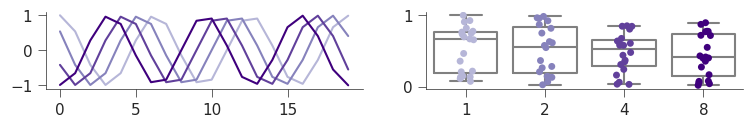

In [9]:
# RGB hex values theme - for summary stats plots
group_names = [1,2,4,8]; group_num = len(group_names)

# get the RGBA from normalized colormap axis
viridis_colors = [cm.Purples(i/(group_num+1)) for i in range(2,group_num+2)]
hex_colors = [f'#{int(r*255):02x}{int(g*255):02x}{int(b*255):02x}' for r, g, b, _ in viridis_colors] # Convert RGBA to HEX
print(hex_colors) # ['#abcfe5', '#6aadd5', '#3787c0', '#0f5ba3', '#08306b']

# validate colors settings work with both major plotting packages
plt.figure(figsize=[9,1]); plt.subplot(121);
for igs, gs in enumerate(group_names): plt.plot(np.cos(np.arange(igs,igs+20)),c=hex_colors[igs]);
tmp = {n: np.random.random(20) for n in group_names};
plt.subplot(122); sns.boxplot(data=tmp,fill=False,color='gray'); sns.stripplot(data=tmp,palette=hex_colors); sns.despine();
plt.show()

# S1a - SLEAP tracking

# S1b - loom trajectory diagram

Group: jy_240311_s16 1 fish
Group: jy_240318_s21 1 fish
Group: jy_240318_s24 1 fish
Group: jy_240516_s6 1 fish
/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S1b


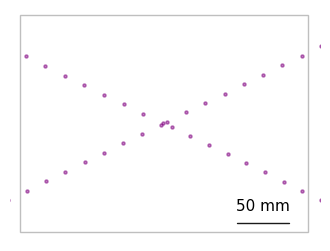

In [ ]:
subpanel = 'S1b'
rep_experiments = ['jy_240311_s16','jy_240318_s21','jy_240318_s24','jy_240516_s6'] # upper left, lower left, upper right, lower right

fig, ax = plt.subplots(figsize=[4,3])
xx1, xx2, xx3, xx4, yy1, yy2, yy3, yy4 = [],[],[],[],[],[],[],[]

for exp in rep_experiments:
  load_path = save_path + exp + '/'; output_path = save_path + exp + '/'
  loom_dur = metadata.loom_dur[exp]; fish_num = metadata.fish_num[exp]
  samples = [] # for csv saving

  fish_num = metadata.fish_num[exp]; loom_dur = metadata.loom_dur[exp]
  rig_mm = metadata.rig_mm[exp]; rig_coord = metadata.rig_coord[exp] # xy of four corners from top left, clockwise
  c1,c2,c3,c4 = rig_coord.split(';');
  x1,y1 = [int(c) for c in c1.split(',')]; x2,y2 = [int(c) for c in c2.split(',')]; x3,y3 = [int(c) for c in c3.split(',')]; x4,y4 = [int(c) for c in c4.split(',')]
  # vid_px = (abs(x1-x2)+abs(y1-y4))/2; scale = rig_mm/vid_px # mm per pixel
  xx1.append(x1); xx2.append(x2); xx3.append(x3); xx4.append(x4)
  yy1.append(y1); yy2.append(y2); yy3.append(y3); yy4.append(y4)

  # load data
  data = np.load(load_path + 'lev0_basics.npz', allow_pickle=True)
  fish_num, scale, fps, frame_num =  data['fish_num'], data['scale'], data['fps'], data['frame_num']
  f_speed, f_bodylength_mm = data['f_speed']*scale, data['f_bodylength_mm']
  f_speed_bd = np.array([(sp/bd) for sp, bd in zip(f_speed, f_bodylength_mm)])
  f_x, f_y = data['f_x'], data['f_y']

  data = np.load(load_path + 'lev0_loom.npz', allow_pickle=True)
  loom_sec, loom_frames, loom_len = data['loom_sec'], data['loom_frames'], data['loom_len']
  loom_on = loom_frames[0]; loom_off = loom_on + loom_len
  loom_x, loom_y = data['loom_x'], data['loom_y']

  print('Group:', exp, fish_num, 'fish')

  # visualize loom trajectory
  plt.scatter(loom_x[loom_on:loom_off:loom_dur*7],loom_y[loom_on:loom_off:loom_dur*7],color='purple',alpha=.5,s=5)

xx1, xx2, xx3, xx4, yy1, yy2, yy3, yy4 = np.mean(xx1), np.mean(xx2), np.mean(xx3), np.mean(xx4),\
                                          np.mean(yy1), np.mean(yy2), np.mean(yy3), np.mean(yy4)
# mean wall positions
ax.add_patch(patches.Rectangle((xx1,yy1),abs(yy1-yy4),abs(xx1-xx2),edgecolor=(0,0,0,0.25), facecolor='none', linewidth=1))

plt.xlim(0,1000); plt.ylim(0,1000); plt.xticks([]); plt.yticks([])

# scale bar
x = np.arange(900-(1000/6),900); y = np.ones(len(x))*80
plt.plot(x,y,c='k',linewidth=1);
plt.text(np.mean(x), np.mean(y)+50,'50 mm', ha='center', fontsize=11, color='black')

for spine in ax.spines.values(): spine.set_visible(False)
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+".pdf",bbox_inches='tight')
plt.show()

# S1c - example raw speeds

jy_240311_s0: 4 fish
jy_240318_s0: 4 fish
jy_240318_s40: 4 fish
jy_240320_s25: 4 fish
/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S1c


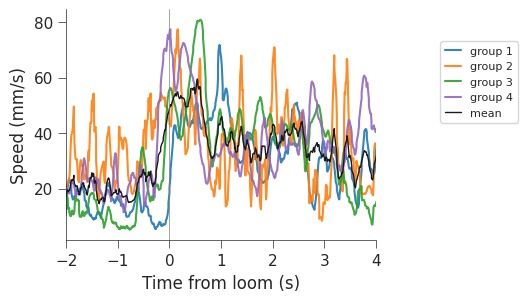

,group1,group2,group3,group4
0,13.477809,11.393614,9.197631,17.040352
1,14.325161,15.244640,9.499034,18.019274
2,15.030132,19.572143,9.852109,19.821803
3,15.933760,19.819823,10.141671,21.485295
4,16.759378,20.272043,10.260055,23.575530
...,...,...,...,...
1447,21.749725,26.311026,26.679759,21.165048
1448,23.635143,28.395746,25.769566,20.905246
1449,20.654561,29.196187,24.857944,21.023302
1450,18.078694,28.152861,23.944741,20.793863


In [ ]:
subpanel = 'S1c'
rep_experiments = ['jy_240311_s0','jy_240318_s0','jy_240318_s40','jy_240320_s25']
samples = [] # for csv saving

for exp in rep_experiments:
  load_path = save_path + exp + '/'; output_path = save_path + exp + '/'

  # load data
  data = np.load(load_path + 'lev0_basics.npz', allow_pickle=True)
  fish_num, scale, fps, frame_num =  data['fish_num'], data['scale'], data['fps'], data['frame_num']
  f_speed = data['f_speed']*scale
  data = np.load(load_path + 'lev0_loom.npz', allow_pickle=True)
  loom_on, loom_len = data['loom_frames'][0], data['loom_len']; loom_off = loom_on + loom_len

  print(f'{exp}: {fish_num} fish')
  group_speed = np.nanmean(f_speed[:,loom_off-int(6*121):loom_off+int(6*121)],axis=0)
  samples.append(group_speed)

# make time_sec relative to tap for plotting
pre = np.linspace(-6,0,6*121); post = np.linspace(0,6,6*121)
rel_time = np.concatenate((pre,post)); rel_sec = np.round(rel_time,2)

# speed in mm/s
plt.figure(figsize=[4,3])
for s, sp in enumerate(samples): plt.plot(rel_sec,sp,alpha=0.9,label=f'group {s+1}')
plt.plot(rel_sec,np.mean(samples,axis=0),linewidth=1,color='k',label='mean')
plt.axvline(0,c='grey',linewidth=0.5);
plt.xlim(-2,4); plt.xlabel('Time from loom (s)'); plt.ylabel('Speed (mm/s)')
plt.legend(bbox_to_anchor=(1.2,0.5),handlelength=1.5,markerscale=0.7,borderaxespad=0.2,fontsize=8)
sns.despine();
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+".pdf",bbox_inches='tight')
plt.show()

# save source data into csv - for time series, save out the visible part
ST, ED = -30, 30; st, ed = -2, 4; fps = 121

series_dict = {}
for i, sample in enumerate(samples):
  col_name = f"group{i+1}"
  series_dict[col_name] = pd.Series(sample)  # auto-fills NaN

df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+'.csv', index=False)

# S1d - baseline speed (1 vs 4)

/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S1d


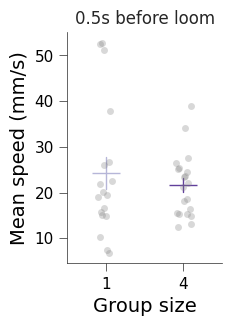

Ns, means, and  sems for data:
1: (N=18) 24.276, 3.470
4: (N=20) 21.614, 1.566

Normality test (Shapiro-Wilk):
Group 1: W = 0.846, p = 7.3970333607e-03
Group 4: W = 0.926, p = 1.3006501744e-01
not all groups are normally distributed → use nonparametric test.

Mann-Whitney U: U = 179.000, p = 9.8833723113e-01


,1fish,4fish
0,15.023667,18.223427
1,7.513113,16.327974
2,19.439798,15.619734
3,26.678565,18.491079
4,19.051338,22.030523
5,6.839146,27.520525
6,52.773217,25.339562
7,22.524238,24.484715
8,51.110427,21.177010
9,21.815116,26.541095


In [ ]:
subpanel = 'S1d'
window_of_interest = [0.5] # sec

for woi in window_of_interest:

  # DATA
  group_sizes = [1,4]; group_values = {n: [] for n in group_sizes}
  hex_colors = ['#b6b6d8', '#61409b']

  for exp in experiments[::]:
    load_path = save_path + exp + '/'; output_path = save_path + exp + '/'
    fish_num = metadata.fish_num[exp];
    if fish_num not in group_sizes: continue

    # load data
    if os.path.exists(load_path + 'lev0_basics.npz') == False: continue
    data = np.load(load_path + 'lev0_basics.npz', allow_pickle=True)
    fps, scale = data['fps'], data['scale']
    f_speed =  data['f_speed']*scale
    data = np.load(load_path + 'lev0_loom.npz', allow_pickle=True)
    loom_on, loom_len = data['loom_frames'][0], data['loom_len']; loom_off = loom_on + loom_len

    # compare pre and post loom 500-ms
    window = int(fps*woi)

    pre_speeds = [np.random.choice(i[:loom_on], size=window, replace=False) for i in f_speed]
    post_speeds = [i[loom_off:loom_off+window] for i in f_speed]


    if fish_num == 1:
      group_values[fish_num].append(np.nanmean(pre_speeds[0]))
    else:
      # get mean of the group if n>1
      group_values[fish_num].append(np.mean([(np.nanmean(pre_speeds[f])) for f in range(fish_num)]))

  # plot
  plt.figure(figsize=[2,3])
  sns.stripplot(data=group_values,color='gray',alpha=0.3,size=5)
  sns.pointplot(data=group_values,palette=hex_colors,linestyle="none",marker="_",estimator='mean',errorbar='se',markersize=20,markeredgewidth=1,errwidth=1);
  plt.xlabel('Group size', fontsize=14, color='black')
  plt.ylabel(f'Mean speed (mm/s)', fontsize=14, color='black')
  plt.xticks(fontsize=11, color='black'); plt.yticks(fontsize=11, color='black')
  sns.despine(); plt.title(f'{woi}s before loom')
  print(figure_path+subpanel)
  plt.savefig(figure_path+subpanel+f".pdf",bbox_inches='tight');
  plt.show()

  # stats
  group_sizes = list(group_values.keys())
  groups = group_values.keys()
  summary_data = group_values.values()
  print("Ns, means, and  sems for data:")
  for id, s in enumerate(summary_data):
    print(f'{group_sizes[id]}: (N={len(s)}) {np.nanmean(s):.3f}, {scipy.stats.sem(s):.3f}')

  ## -- 1. Test for normality in each group -- ##
  print("\nNormality test (Shapiro-Wilk):")
  normality_results = {}
  for group, data in zip(groups, summary_data):
    stat, p = stats.shapiro(data)
    normality_results[group] = {'W': stat, 'p': p}
  for g, res in normality_results.items():
    print(f"Group {g}: W = {res['W']:.3f}, p = {res['p']:.10e}")

  is_normal = all(res['p'] > 0.05 for res in normality_results.values());
  if is_normal: print("all groups are normally distributed \u2192 use parametric test.")
  else: print("not all groups are normally distributed \u2192 use nonparametric test.")

  ## -- 2. Group comparisons (& post hoc test) -- ##
  unique_groups = len(groups);
  if unique_groups == 2:
    groups = list(groups); summary_data = group_values
    #  Two groups: t-test or Mann-Whitney
    if is_normal:
      stat, p = stats.ttest_ind(summary_data[groups[0]], summary_data[groups[1]])
      print(f"\nT-test: t = {stat:.3f}, p = {p:.10e}")
    else:
      stat, p = stats.mannwhitneyu(summary_data[groups[0]], summary_data[groups[1]])
      print(f"\nMann-Whitney U: U = {stat:.3f}, p = {p:.10e}")

  elif unique_groups > 2:
    if is_normal: # One-way ANOVA
      summary_data = list(group_values.values())
      groups = list(group_values.keys())
      df = pd.DataFrame({'data': np.concatenate(summary_data), 'group': np.repeat(groups, [len(d) for d in summary_data])})
      # Define the formula
      formula = 'data ~ group'
      # Fit the model
      model = smf.ols(formula, data=df).fit()
      anova_table = sm.stats.anova_lm(model, typ=2)
      print("\nOne-way ANOVA:\n", anova_table)
      if anova_table['PR(>F)'][0] < 0.05:
        flat_data = [val for sublist in summary_data for val in sublist]
        groups = [group_names[i] for i, sublist in enumerate(summary_data) for _ in sublist]
        tukey = pairwise_tukeyhsd(endog=flat_data, groups=groups, alpha=0.05)
        print("\nTukey's HSD post hoc test:\n", tukey.summary())
        for res in tukey._results_table.data[1:]:
          g1, g2, p = res[0], res[1], res[4]

    else: # Kruskal-Wallis test
      stat, p = stats.kruskal(*summary_data)
      print(f"\nKruskal-Wallis H-test: H = {stat:.3f}, p = {p:.10e}")
      if p < 0.05:
        # Dunn's post hoc test with Bonferroni correction
        data_for_dunn = list(summary_data); group_for_dunn = list(groups)
        dunn = scikit.posthoc_dunn(data_for_dunn, p_adjust='bonferroni')
        print("\nDunn's post hoc test with bonferroni correction: ",group_for_dunn)
        print(dunn)
  # save source data into csv
  series_dict = {}
  for key, values in group_values.items(): series_dict[f'{key}fish'] = pd.Series(values)

  df = pd.DataFrame(series_dict)
  display(df)
  df.to_csv(csv_path+subpanel+f'.csv', index=False)

# S1e+f

In [ ]:
from scipy.stats import gaussian_kde
from scipy.signal import find_peaks
from sklearn.mixture import GaussianMixture
from scipy.stats import norm

In [ ]:
group_sizes = [1,4]; group_values = {n: [] for n in group_sizes}
hex_colors = ['#b6b6d8', '#61409b']

dt_sec = 0.05  # sampling interval for delta heading
fps = 121      # frames per second (adjust as needed)
sliding_window = 5 # frames to smooth data

# stimulus-relative windows (in sec)
window_times = {'baseline': (-36, 6)}

# prepare pooling structure
group_sizes = [1, 4]  # example
pooled_speeds = {g: {w: [] for w in window_times} for g in group_sizes}

for exp in experiments:
  load_path = save_path + exp + '/'
  fish_num = metadata.fish_num[exp]
  if fish_num not in group_sizes: continue

  # load heading data
  data = np.load(load_path + 'lev0_basics.npz', allow_pickle=True)
  scale = data['scale']
  f_speed = data['f_speed']*scale  # shape: fish_num x frame_num

  # load stimulus frame
  data = np.load(load_path + 'lev0_loom.npz', allow_pickle=True)
  loom_on, loom_len = data['loom_frames'][0], data['loom_len']; loom_off = loom_on + loom_len
  loom_frame = loom_off

  # use sliding window max
  speed_win = np.array([[np.max(speed[i:i + sliding_window])
            for i in range(len(speed) - sliding_window + 1)] for speed in f_speed])

  # loop over windows
  for w_name, (t_start, t_end) in window_times.items():
    # compute start and stop frame indices relative to tap
    i0 = loom_frame + int(t_start * fps)
    i1 = loom_frame + int(t_end * fps)
    if i1>i0:
      [pooled_speeds[fish_num][w_name].append(speed[i0:i1]) for speed in speed_win]

# concatenate across experiments
for g in pooled_speeds:
  for w_name, _ in window_times.items():
    if pooled_speeds[g][w_name]:  # avoid empty lists
      pooled_speeds[g][w_name] = np.concatenate(pooled_speeds[g][w_name])
    else:
      pooled_speeds[g][w_name] = np.array([])

# run test to see if two samples come from the same continuous distribution
g1, g2 = [g for g in group_sizes]
x = np.array(pooled_speeds[g1]['baseline'])
y = np.array(pooled_speeds[g2]['baseline'])

x = x[np.isfinite(x)]
y = y[np.isfinite(y)]

stat, p = stats.ks_2samp(x, y)
print(f"KS test: D = {stat:.3f}, p = {p:.3e}")

if p > 0.05:
  print("The distributions are the same, pool distribution.")
else:
  print("The distributions are different, do not pool distribution.")

KS test: D = 0.032, p = 3.060e-66
The distributions are different, do not pool distribution.


## S1e - Gaussian fitting of baseline speed

In [ ]:
subpanel = 'S1e'

# fit Gaussian separately
k_component = 4
cv_type = 'diag'
baseline_gaussian_df = {g: {} for g in group_sizes}

for g in group_sizes:
  swims=np.array(pooled_speeds[g]['baseline']) # inputs

  # Fit a GMM
  gmm = GaussianMixture(n_components=k_component, n_init=20, covariance_type=cv_type, \
                        random_state=42, reg_covar=1e-3)
  swims = swims.reshape(-1, 1)  # Reshape for GMM input
  gmm.fit(swims)

  # Get the means, covariances, and weights of the Gaussians
  means = gmm.means_.flatten()  # Means of the Gaussian components
  covariances = gmm.covariances_.flatten()  # Covariances (assuming diagonal)
  weights = gmm.weights_  # Weights of the Gaussian components
  # Get the probability that each value in swims belongs to each Gaussian
  probabilities = gmm.predict_proba(swims)

  # sort the component
  sort_idx = np.argsort(means)
  means = means[sort_idx]
  covariances = covariances[sort_idx] # change if not covariance_type != diag
  weights = weights[sort_idx]
  probabilities = probabilities[:, sort_idx]
  stds = np.sqrt(covariances)

  print(f'{g} fish:')
  print(f'Means: {means}'); print(f'Covariances: {covariances}'); print(f'Weights: {weights}')

  # save in df for future references
  baseline_gaussian_df[g]['data'] = swims
  baseline_gaussian_df[g]['means'] = means
  baseline_gaussian_df[g]['stds'] = stds
  baseline_gaussian_df[g]['weights'] = weights
  baseline_gaussian_df[g]['probabilities'] = probabilities

# combine
plt.figure(figsize=(4,3))
for ig,g in enumerate(group_sizes):
  # load gaussian fit
  data, means, stds, weights =  baseline_gaussian_df[g]['data'], baseline_gaussian_df[g]['means'], \
  baseline_gaussian_df[g]['stds'], baseline_gaussian_df[g]['weights']
  # Mark the threshold
  m1, s1, w1 = means[1], stds[1], weights[1]
  m2, s2, w2 = means[2], stds[2], weights[2]

  # Solve w1*N(x|m1,s1) = w2*N(x|m2,s2)
  a = 1/(2*s1**2) - 1/(2*s2**2)
  b = m2/(s2**2) - m1/(s1**2)
  c = (m1**2)/(2*s1**2) - (m2**2)/(2*s2**2) + np.log((w2*s1)/(w1*s2))

  roots = np.roots([a, b, c])
  escape_threshold = np.max(roots.real)  # pick the higher-speed crossing
  baseline_gaussian_df[g]['escape_threshold'] = escape_threshold

  plt.hist(data.ravel(), bins=150, density=True, alpha=0.4, color='gray')
  x = np.linspace(data.ravel().min(), data.ravel().max(), 1000)
  for k in range(len(means)):
      plt.plot(x, weights[k] * norm.pdf(x, means[k], stds[k]), lw=1, color=hex_colors[ig])
  plt.axvline(escape_threshold, color=hex_colors[ig],ls=':',lw=1,label=f'{g}-fish {escape_threshold:.2f} mm/s')

plt.legend(loc=[0.5,0.2],fontsize=10); plt.title(f'Baseline swimming')
plt.xlabel("Speed (mm/s)"); plt.ylabel("Probability density")
sns.despine();
print(figure_path+subpanel)
# plt.savefig(figure_path+subpanel+f".pdf",bbox_inches='tight')
plt.show()

# save source data into csv
series_dict = {}
for gs, values in group_values.items():
  series_dict[f'{gs}fish_data'] = pd.Series(baseline_gaussian_df[gs]['data'].flatten())
  series_dict[f'{gs}fish_means'] = pd.Series(baseline_gaussian_df[gs]['means'])
  series_dict[f'{gs}fish_stds'] = pd.Series(baseline_gaussian_df[gs]['stds'])
  series_dict[f'{gs}fish_weights'] = pd.Series(baseline_gaussian_df[gs]['weights'])
  series_dict[f'{gs}fish_escape_threshold'] = pd.Series(baseline_gaussian_df[gs]['escape_threshold'])

df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+f'.csv', index=False)

,1fish_data,1fish_means,1fish_stds,1fish_weights,1fish_escape_threshold,4fish_data,4fish_means,4fish_stds,4fish_weights,4fish_escape_threshold
0,4.612124,10.199391,5.099614,0.479556,39.184523,15.010089,10.145683,4.434265,0.458472,36.60044
1,4.612124,26.465410,8.003960,0.304376,NaN,14.042669,25.603703,7.669233,0.269435,NaN
2,4.612124,48.272124,11.067145,0.166803,NaN,12.337685,46.541995,10.775915,0.207264,NaN
3,4.523279,91.375980,20.752295,0.049265,NaN,10.850981,74.432859,24.321649,0.064829,NaN
4,4.523279,NaN,NaN,NaN,NaN,10.850981,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
406555,NaN,NaN,NaN,NaN,NaN,16.998379,NaN,NaN,NaN,NaN
406556,NaN,NaN,NaN,NaN,NaN,16.998379,NaN,NaN,NaN,NaN
406557,NaN,NaN,NaN,NaN,NaN,16.998379,NaN,NaN,NaN,NaN
406558,NaN,NaN,NaN,NaN,NaN,16.998379,NaN,NaN,NaN,NaN


## S1f - escape latency (1 vs 4)

/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S1f


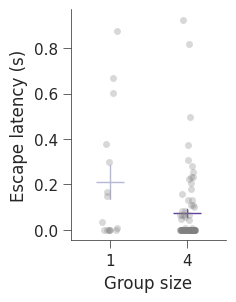


Escape probability:
Group 1: 15/18 escaped (83.3%)
Group 4: 80/80 escaped (100.0%)

Ns, means, and  sems for data:
1: (N=15) 0.212, 0.075
4: (N=80) 0.073, 0.018

Normality test (Shapiro-Wilk):
Group 1: W = 0.768, p = 1.4682348870e-03
Group 4: W = 0.514, p = 7.7528240751e-15
not all groups are normally distributed → use nonparametric test.

Mann-Whitney U: U = 780.000, p = 3.8531146856e-02


,1fish,4fish
0,0.000000,0.000000
1,0.000000,0.206612
2,0.000000,0.008264
3,0.033058,0.066116
4,0.165289,0.000000
...,...,...
75,NaN,0.082645
76,NaN,0.000000
77,NaN,0.000000
78,NaN,0.000000


In [ ]:
# classify post stim swim by threshold
subpanel = 'S1f'
group_sizes = [1,4]
escape_latency = {g:[] for g in group_sizes}
escape_window = [0,1]

dt_sec = 0.05  # sampling interval for delta heading
fps = 121      # frames per second (adjust as needed)
sliding_window = 5 # frames to smooth data

# stimulus-relative windows (in sec)
window_times = {'baseline': (-30, 0)}

# prepare pooling structure
group_sizes = [1, 4]  # example
pooled_speeds = {g: {w: [] for w in window_times} for g in group_sizes}

for exp in experiments:
  load_path = save_path + exp + '/'
  fish_num = metadata.fish_num[exp]
  if fish_num not in group_sizes: continue

  # load heading data
  data = np.load(load_path + 'lev0_basics.npz', allow_pickle=True)
  scale = data['scale']
  f_speed = data['f_speed']*scale  # shape: fish_num x frame_num

  # load stimulus frame
  data = np.load(load_path + 'lev0_loom.npz', allow_pickle=True)
  loom_on, loom_len = data['loom_frames'][0], data['loom_len']; loom_off = loom_on + loom_len
  loom_frame = loom_off

  # use sliding window max
  speed_win = np.array([[np.max(speed[i:i + sliding_window])
            for i in range(len(speed) - sliding_window + 1)] for speed in f_speed])

  i0 = loom_frame + int(escape_window[0] * fps)
  i1 = loom_frame + int(escape_window[1] * fps)

  for f in range(fish_num):
    post_speed = speed_win[f][i0:i1]
    threshold = baseline_gaussian_df[fish_num]['escape_threshold']
    above = np.where(post_speed > threshold)[0]
    if len(above) > 0:
        first_idx = above[0]
        latency = first_idx / fps
        escape_latency[fish_num].append(latency)
    else:
        escape_latency[fish_num].append(np.nan)

# escape_latency
group_values = escape_latency
hex_colors = ['#b6b6d8', '#61409b']

# plot
plt.figure(figsize=[2,3])
sns.stripplot(data=group_values,color='gray',alpha=0.3,size=5)
sns.pointplot(data=group_values,palette=hex_colors,linestyle="none",marker="_",estimator='mean',errorbar='se',markersize=20,markeredgewidth=1,errwidth=1);
plt.xlabel('Group size'); plt.ylabel(f'Escape latency (s)')
sns.despine();
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+f".pdf",bbox_inches='tight');
plt.show()

# stats
group_sizes = list(group_values.keys())
groups = group_values.keys()
summary_data = group_values.values()

print("\nEscape probability:")
for g, vals in group_values.items():
    vals = np.array(vals)
    n_total = len(vals)
    n_escape = np.sum(~np.isnan(vals))
    print(f"Group {g}: {n_escape}/{n_total} escaped ({100*n_escape/n_total:.1f}%)")

## -- 0. remove NaN values for subsequent stats -- ##
summary_data = {i: [] for i in groups}
for i, data in group_values.items():
  tmp = np.array(group_values[i])
  summary_data[i] = tmp[~np.isnan(tmp)]
summary_data = list(summary_data.values())
group_values = {g:data for g, data in zip(groups,summary_data)}

print("\nNs, means, and  sems for data:")
for id, s in enumerate(summary_data):
  print(f'{group_sizes[id]}: (N={len(s)}) {np.nanmean(s):.3f}, {scipy.stats.sem(s,nan_policy='omit'):.3f}')

## -- 1. Test for normality in each group -- ##
print("\nNormality test (Shapiro-Wilk):")
normality_results = {}
for group, data in zip(groups, summary_data):
  stat, p = stats.shapiro(data)
  normality_results[group] = {'W': stat, 'p': p}
for g, res in normality_results.items():
  print(f"Group {g}: W = {res['W']:.3f}, p = {res['p']:.10e}")

is_normal = all(res['p'] > 0.05 for res in normality_results.values());
if is_normal: print("all groups are normally distributed \u2192 use parametric test.")
else: print("not all groups are normally distributed \u2192 use nonparametric test.")

## -- 2. Group comparisons (& post hoc test) -- ##
unique_groups = len(groups);
if unique_groups == 2:
  groups = list(groups); summary_data = group_values
  #  Two groups: t-test or Mann-Whitney
  if is_normal:
    stat, p = stats.ttest_ind(summary_data[groups[0]], summary_data[groups[1]])
    print(f"\nT-test: t = {stat:.3f}, p = {p:.10e}")
  else:
    stat, p = stats.mannwhitneyu(summary_data[groups[0]], summary_data[groups[1]])
    print(f"\nMann-Whitney U: U = {stat:.3f}, p = {p:.10e}")

elif unique_groups > 2:
  if is_normal: # One-way ANOVA
    summary_data = list(group_values.values())
    groups = list(group_values.keys())
    df = pd.DataFrame({'data': np.concatenate(summary_data), 'group': np.repeat(groups, [len(d) for d in summary_data])})
    # Define the formula
    formula = 'data ~ group'
    # Fit the model
    model = smf.ols(formula, data=df).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    print("\nOne-way ANOVA:\n", anova_table)
    if anova_table['PR(>F)'][0] < 0.05:
      flat_data = [val for sublist in summary_data for val in sublist]
      groups = [group_names[i] for i, sublist in enumerate(summary_data) for _ in sublist]
      tukey = pairwise_tukeyhsd(endog=flat_data, groups=groups, alpha=0.05)
      print("\nTukey's HSD post hoc test:\n", tukey.summary())
      for res in tukey._results_table.data[1:]:
        g1, g2, p = res[0], res[1], res[4]

  else: # Kruskal-Wallis test
    stat, p = stats.kruskal(*summary_data)
    print(f"\nKruskal-Wallis H-test: H = {stat:.3f}, p = {p:.10e}")
    if p < 0.05:
      # Dunn's post hoc test with Bonferroni correction
      data_for_dunn = list(summary_data); group_for_dunn = list(groups)
      dunn = scikit.posthoc_dunn(data_for_dunn, p_adjust='bonferroni')
      print("\nDunn's post hoc test with bonferroni correction: ",group_for_dunn)
      print(dunn)

# save source data into csv
series_dict = {}
for key, values in group_values.items(): series_dict[f'{key}fish'] = pd.Series(values)

df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+f'.csv', index=False)

# S1g - baseline travel dist (1 vs 4)

/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S1g


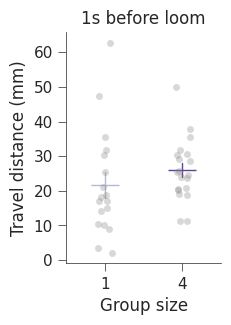

Ns, means, and  sems for data:
1: (N=18) 21.695, 3.629
4: (N=20) 25.971, 2.008

Normality test (Shapiro-Wilk):
Group 1: W = 0.899, p = 5.5978260802e-02
Group 4: W = 0.951, p = 3.8326041619e-01
all groups are normally distributed → use parametric test.

T-test: t = -1.059, p = 2.9670544704e-01


,1fish,4fish
0,15.105542,11.371326
1,17.183732,18.665897
2,35.601734,23.587615
3,30.453343,20.759261
4,17.071778,11.243404
5,18.284301,37.896724
6,62.776211,29.097548
7,14.271833,49.928104
8,25.473448,25.646356
9,2.128802,28.499356


In [ ]:
subpanel = 'S1g'
window_of_interest = [1] # sec

for woi in window_of_interest:

  # DATA
  group_sizes = [1,4]; group_values = {n: [] for n in group_sizes}
  hex_colors = ['#b6b6d8', '#61409b']

  for exp in experiments[::]:
    load_path = save_path + exp + '/'; output_path = save_path + exp + '/'
    fish_num = metadata.fish_num[exp];
    if fish_num !=1 and fish_num !=4: continue

    # load data
    data = np.load(load_path + 'lev0_basics.npz', allow_pickle=True)
    fps, scale = data['fps'], data['scale']
    f_speed =  data['f_speed']*scale
    data = np.load(load_path + 'lev0_loom.npz', allow_pickle=True)
    loom_on, loom_len = data['loom_frames'][0], data['loom_len']; loom_off = loom_on + loom_len

    # compare pre and post tap 500-ms
    window = int(fps*woi); dt = 1/fps
    f_travel = [np.trapezoid(sp[loom_off-window:loom_off],dx=dt) for sp in f_speed]

    # take mean of the group if >1 fish
    if fish_num == 1:
      group_values[fish_num].append(f_travel[0])
    else:
      group_values[fish_num].append(np.mean([f_travel[f] for f in range(fish_num)]))

  # plot
  plt.figure(figsize=[2,3])
  sns.stripplot(data=group_values,color='gray',alpha=0.3,size=5) #,legend=group_values.keys());
  sns.pointplot(data=group_values,palette=hex_colors,linestyle="none",marker="_",estimator='mean',errorbar='se',markersize=20,markeredgewidth=1,errwidth=1);
  plt.xlabel('Group size'); plt.ylabel('Travel distance (mm)')
  sns.despine(); plt.title(f'{woi}s before loom')
  print(figure_path+subpanel)
  plt.savefig(figure_path+subpanel+f".pdf",bbox_inches='tight');
  plt.show()

  # stats
  group_sizes = list(group_values.keys())
  groups = group_values.keys()
  summary_data = group_values.values()
  print("Ns, means, and  sems for data:")
  for id, s in enumerate(summary_data):
    print(f'{group_sizes[id]}: (N={len(s)}) {np.nanmean(s):.3f}, {scipy.stats.sem(s):.3f}')

  ## -- 1. Test for normality in each group -- ##
  print("\nNormality test (Shapiro-Wilk):")
  normality_results = {}
  for group, data in zip(groups, summary_data):
    stat, p = stats.shapiro(data)
    normality_results[group] = {'W': stat, 'p': p}
  for g, res in normality_results.items():
    print(f"Group {g}: W = {res['W']:.3f}, p = {res['p']:.10e}")

  is_normal = all(res['p'] > 0.05 for res in normality_results.values());
  if is_normal: print("all groups are normally distributed \u2192 use parametric test.")
  else: print("not all groups are normally distributed \u2192 use nonparametric test.")

  ## -- 2. Group comparisons (& post hoc test) -- ##
  unique_groups = len(groups);
  if unique_groups == 2:
    groups = list(groups); summary_data = group_values
    #  Two groups: t-test or Mann-Whitney
    if is_normal:
      stat, p = stats.ttest_ind(summary_data[groups[0]], summary_data[groups[1]])
      print(f"\nT-test: t = {stat:.3f}, p = {p:.10e}")
    else:
      stat, p = stats.mannwhitneyu(summary_data[groups[0]], summary_data[groups[1]])
      print(f"\nMann-Whitney U: U = {stat:.3f}, p = {p:.10e}")

  elif unique_groups > 2:
    if is_normal: # One-way ANOVA
      summary_data = list(group_values.values())
      groups = list(group_values.keys())
      df = pd.DataFrame({'data': np.concatenate(summary_data), 'group': np.repeat(groups, [len(d) for d in summary_data])})
      # Define the formula
      formula = 'data ~ group'
      # Fit the model
      model = smf.ols(formula, data=df).fit()
      anova_table = sm.stats.anova_lm(model, typ=2)
      print("\nOne-way ANOVA:\n", anova_table)
      if anova_table['PR(>F)'][0] < 0.05:
        flat_data = [val for sublist in summary_data for val in sublist]
        groups = [group_names[i] for i, sublist in enumerate(summary_data) for _ in sublist]
        tukey = pairwise_tukeyhsd(endog=flat_data, groups=groups, alpha=0.05)
        print("\nTukey's HSD post hoc test:\n", tukey.summary())
        for res in tukey._results_table.data[1:]:
          g1, g2, p = res[0], res[1], res[4]

    else: # Kruskal-Wallis test
      stat, p = stats.kruskal(*summary_data)
      print(f"\nKruskal-Wallis H-test: H = {stat:.3f}, p = {p:.10e}")
      if p < 0.05:
        # Dunn's post hoc test with Bonferroni correction
        data_for_dunn = list(summary_data); group_for_dunn = list(groups)
        dunn = scikit.posthoc_dunn(data_for_dunn, p_adjust='bonferroni')
        print("\nDunn's post hoc test with bonferroni correction: ",group_for_dunn)
        print(dunn)
  # save source data into csv
  series_dict = {}
  for key, values in group_values.items(): series_dict[f'{key}fish'] = pd.Series(values)

  df = pd.DataFrame(series_dict)
  display(df)
  df.to_csv(csv_path+subpanel+f'.csv', index=False)

# S1h - example trajectory (1248)


Group: jy_240318_s21 1 fish
/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S1h


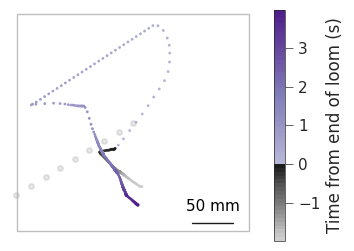

,f1_x,f1_y
0,531.292236,235.648959
1,529.562634,236.400845
2,527.293372,236.533417
3,525.521729,236.493024
4,523.827405,236.565433
...,...,...
356,512.719312,156.542825
357,513.484912,156.350644
358,514.844214,156.158563
359,516.135681,155.986066



Group: jy_240318_s6 2 fish
/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S1h


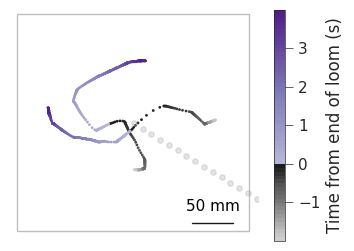

,f1_x,f1_y,f2_x,f2_y
0,501.595789,308.576556,828.888257,524.233533
1,503.329266,308.525653,828.571143,524.330408
2,504.943201,308.451898,827.199915,523.210071
3,506.488770,308.431958,825.848755,522.019458
4,507.987274,308.418176,825.134607,521.371436
...,...,...,...,...
357,541.369885,780.033044,155.735608,571.452576
358,542.935144,780.047717,155.696777,573.749036
359,544.397449,780.063403,155.121292,575.366833
360,544.715344,780.085144,154.009732,576.336829



Group: jy_240320_s11 8 fish
/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S1h


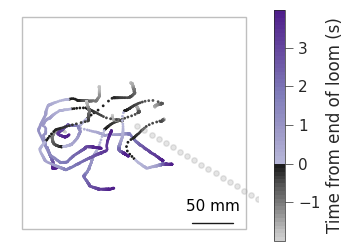

,f1_x,f1_y,f2_x,f2_y,f3_x,f3_y,f4_x,f4_y,f5_x,f5_y,f6_x,f6_y,f7_x,f7_y,f8_x,f8_y
0,487.849426,684.498767,223.830991,471.414832,508.673560,583.503125,620.563428,524.613135,412.867175,544.436316,359.909180,668.871021,308.503833,604.549463,584.334534,580.523730
1,487.365704,684.531079,222.323538,472.262469,508.805652,583.486255,620.569714,524.606653,412.823334,543.517114,359.895990,668.756934,308.553931,604.348755,584.348706,580.613733
2,486.868701,684.603210,220.806031,473.258531,508.934814,583.480884,620.561926,524.601489,412.797797,542.166467,359.905804,668.608044,308.569849,604.129456,584.385315,580.723010
3,485.839801,684.591138,219.275119,474.452490,509.051086,583.489331,620.591541,525.169470,412.760266,540.794824,359.940564,668.433105,308.611884,602.908496,584.414441,580.786609
4,487.063544,684.516541,217.865704,475.661312,509.131555,583.479089,620.580188,525.753772,412.735754,540.442395,359.966083,668.202734,308.643518,601.694214,584.443030,580.865710
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
358,616.416443,348.428003,232.107029,454.603461,412.574219,228.169437,652.413135,332.110242,184.485440,316.127454,362.327039,401.995209,408.767847,476.430017,475.311572,368.432410
359,616.400964,348.448413,233.233044,455.928363,414.323621,228.237946,652.474756,332.101880,185.407672,316.245911,363.839520,403.211719,408.873627,476.515375,476.651935,368.158887
360,616.393787,348.472778,234.835873,456.742212,415.958966,228.314328,652.527710,332.100098,185.753061,316.350171,365.251184,402.673907,408.979852,476.667389,476.933734,367.943427
361,616.356482,348.456482,236.556693,458.325000,416.971466,228.422491,652.554175,332.110529,187.078815,316.383801,366.625433,401.450220,409.040894,476.875433,477.211383,367.790643


In [ ]:
subpanel = 'S1h'
rep_experiments = ['jy_240318_s21','jy_240318_s6','jy_240320_s11'] #

for exp in rep_experiments:
  load_path = save_path + exp + '/'; output_path = save_path + exp + '/'
  samples_x = []; samples_y = [] # for csv saving

  fish_num = metadata.fish_num[exp]; loom_dur = metadata.loom_dur[exp]
  rig_mm = metadata.rig_mm[exp]; rig_coord = metadata.rig_coord[exp] # xy of four corners from top left, clockwise
  c1,c2,c3,c4 = rig_coord.split(';');
  x1,y1 = [int(c) for c in c1.split(',')]; x2,y2 = [int(c) for c in c2.split(',')]; x3,y3 = [int(c) for c in c3.split(',')]; x4,y4 = [int(c) for c in c4.split(',')]
  vid_px = (abs(x1-x2)+abs(y1-y4))/2; scale = rig_mm/vid_px # mm per pixel

  # load data
  data = np.load(load_path + 'lev0_basics.npz', allow_pickle=True)
  fish_num, scale, fps, frame_num =  data['fish_num'], data['scale'], data['fps'], data['frame_num']
  f_speed, f_bodylength_mm = data['f_speed']*scale, data['f_bodylength_mm']
  f_speed_bd = np.array([(sp/bd) for sp, bd in zip(f_speed, f_bodylength_mm)])
  f_x, f_y = data['f_x'], data['f_y']

  data = np.load(load_path + 'lev0_loom.npz', allow_pickle=True)
  loom_sec, loom_frames, loom_len = data['loom_sec'], data['loom_frames'], data['loom_len']
  loom_on = loom_frames[0]; loom_off = loom_on + loom_len
  loom_x, loom_y = data['loom_x'], data['loom_y']

  print('\nGroup:', exp, fish_num, 'fish')
  # windows of plotting # 2+4 sec peri loom
  pre, post = 2, 4 # in sec before and after tap
  start = loom_off-int(pre*fps); stop = loom_off+int(post*fps)

  # trajectories # colored by time position
  fig, ax = plt.subplots(figsize=[4,3])
  ax.add_patch(patches.Rectangle((x1,y1),abs(y1-y4),abs(x1-x2),edgecolor=(0,0,0,0.25), facecolor='none', linewidth=1))

  # Define custom hybrid colormap
  cmap1 = plt.colormaps['Greys']; cmap2 = plt.colormaps['Purples']
  colors = np.vstack((cmap1(np.linspace(0.3,0.9,20)), cmap2(np.linspace(0.4,0.9,40)))) # ratio of cmap used, amount of slicing
  combined_cmap = mcolors.ListedColormap(colors);
  combined_time = (np.arange(start,stop)-loom_off)/fps

  for f in range(fish_num):
    plt.scatter(f_x[f][start:stop:2],f_y[f][start:stop:2],c=combined_time[::2],cmap=combined_cmap,s=1)
    samples_x.append(f_x[f][start:stop:2]);
    samples_y.append(f_y[f][start:stop:2])
  plt.colorbar(label='Time from end of loom (s)')
  # visualize loom trajectory
  plt.scatter(loom_x[loom_on:loom_off:20],loom_y[loom_on:loom_off:20],color='darkgrey',alpha=.3,s=15)

  plt.xlim(0,1000); plt.ylim(0,1000); plt.xticks([]); plt.yticks([])
  # scale bar
  x = np.arange(900-(1000/6),900); y = np.ones(len(x))*80
  plt.plot(x,y,c='k',linewidth=1);
  plt.text(np.mean(x), np.mean(y)+50,'50 mm', ha='center', fontsize=11, color='black')
  for spine in ax.spines.values(): spine.set_visible(False)
  print(figure_path+subpanel)
  plt.savefig(figure_path+subpanel+f"-{fish_num}fish.pdf",bbox_inches='tight')
  plt.show()

  # save source data into csv - for time series, save out the visible part
  series_dict = {}
  for i, (xx, yy) in enumerate(zip(samples_x,samples_y)):
    col_name = f"f{i+1}_x"; series_dict[col_name] = pd.Series(xx)
    col_name = f"f{i+1}_y"; series_dict[col_name] = pd.Series(yy)

  df = pd.DataFrame(series_dict)
  display(df)
  df.to_csv(csv_path+subpanel+f'-{fish_num}fish.csv', index=False)

# S1i - Δ speed time series (1248)

/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S1i


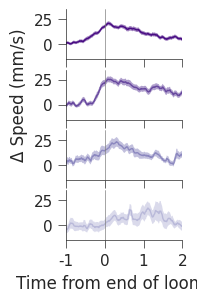

N = [22, 20, 18, 18]


,1fish_1,1fish_2,1fish_3,1fish_4,1fish_5,1fish_6,1fish_7,1fish_8,1fish_9,1fish_10,...,8fish_167,8fish_168,8fish_169,8fish_170,8fish_171,8fish_172,8fish_173,8fish_174,8fish_175,8fish_176
0,2.144487,1.143382,-14.030848,2.402840,-4.530696,17.862135,27.504797,21.026120,0.350765,-17.996601,...,-7.250846,7.381649,-3.783397,43.195179,12.321192,33.053181,-4.337514,11.687398,-2.628904,-10.994987
1,1.827538,1.193161,-13.949455,5.363882,-3.984653,19.456692,27.504797,16.839374,-0.907746,-17.374374,...,-7.612575,11.540681,-5.631501,50.399310,12.008100,34.117897,-3.797599,11.468662,-2.999241,-10.770105
2,-0.087710,0.081868,-10.095660,7.490787,-4.923797,23.170989,27.504797,6.940640,-2.013502,-17.632306,...,-7.731339,15.725657,-5.738870,53.351655,13.018305,35.182613,-3.090547,12.056786,-4.422532,-9.872190
3,-1.662199,0.220676,-3.119730,10.239566,-5.508921,26.742546,27.504797,-3.619585,-1.189834,-17.999867,...,-8.206636,20.126252,-5.776101,56.304000,11.350783,36.247329,-2.065852,11.090196,-5.577814,-9.868496
4,-2.895930,1.178133,3.983854,12.782929,-5.613202,28.679305,27.504797,-8.322090,0.313897,-18.063591,...,-8.405558,24.742467,-5.435598,59.256346,9.523940,37.312045,-1.463606,9.186754,-5.178542,-9.904654
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
358,-6.918594,-2.981021,-0.148426,13.145150,8.019042,1.204470,-4.642693,-5.288295,-6.255257,-13.733352,...,-5.361873,40.262130,8.722205,5.415371,43.921761,11.450720,25.674795,-0.557360,-1.444327,-9.615675
359,-6.477405,-3.693861,-1.530506,13.222711,6.439592,1.597298,-15.651708,-4.786343,-6.317937,-11.888041,...,-7.558083,29.430777,5.865619,3.526608,46.159407,10.080415,23.476814,-1.369711,-2.571157,-9.091697
360,-7.705630,-4.122867,-2.207596,13.751988,4.363669,2.153649,-22.121575,-4.712794,-6.380618,-10.671636,...,-8.402345,21.598295,3.486774,2.801420,48.923413,9.455805,21.034401,-2.723603,-4.507933,-10.446035
361,-7.815678,-4.434018,-3.272011,14.732982,2.189819,4.256862,-24.052296,-5.067648,-6.443298,-8.721938,...,-9.168353,16.764683,2.769623,3.239806,51.569525,7.563549,19.468229,-3.167849,-4.455155,-11.592686


In [ ]:
subpanel = 'S1i'
group_sizes = [1,2,4,8]; group_values = {n: [] for n in group_sizes}
hex_colors = ['#b6b6d8', '#8682bc', '#61409b', '#3f007d']

for exp in experiments[::]:
  load_path = save_path + exp + '/'; output_path = save_path + exp + '/'
  fish_num = metadata.fish_num[exp];
  if fish_num ==6: continue

  # load data
  data = np.load(load_path + 'lev0_basics.npz', allow_pickle=True)
  scale, f_bodylength_mm = data['scale'], data['f_bodylength_mm']
  f_speed = data['f_speed']*scale
  data = np.load(load_path + 'lev0_loom.npz', allow_pickle=True)
  loom_on, loom_len = data['loom_frames'][0], data['loom_len']; loom_off = loom_on + loom_len

  # get 30-sec x(121 fps) before and after tap get same legnth of arrays
  for f in range(fish_num):
    group_values[fish_num].append((f_speed[f][loom_off-int(30*121):loom_off+int(30*121)])-np.mean(f_speed[f][loom_off-int(30*121):loom_off]))
  # break

# make time_sec relative to tap for plotting
pre = np.linspace(-30,0,30*121); post = np.linspace(0,30,30*121)
rel_time = np.concatenate((pre,post)); rel_sec = np.round(rel_time,2)

group_sizes = [8,4,2,1]
hex_colors = ['#3f007d','#61409b','#8682bc','#b6b6d8']
# PLOT # mean+sem
plt.figure(figsize=[1.5,3])
for i, gs in enumerate(group_sizes):
  plt.subplot(len(group_sizes),1,i+1)
  plt.plot(rel_sec,np.mean(group_values[gs],axis=0),linewidth=1,alpha=0.9, label=f'group of {gs}', color=hex_colors[i])
  plt.fill_between(rel_sec,np.mean(group_values[gs],axis=0)-stats.sem(group_values[gs],axis=0,nan_policy='omit'), \
                  np.nanmean(group_values[gs],axis=0)+stats.sem(group_values[gs],axis=0, nan_policy='omit'),alpha=0.5, color=hex_colors[i],linewidth=0)

  plt.axvline(0,c='grey',linestyle='-',linewidth=0.5);
  plt.xlim(-1,2); plt.ylim(-15,35);
  if i==1: plt.ylabel('Δ Speed (mm/s)')
  plt.xticks([-1,0,1,2],[])
  if i==len(group_sizes)-1: plt.xticks([-1,0,1,2],[-1,0,1,2])
  if i==len(group_sizes)-1: plt.xlabel('Time from end of loom (s)');

sns.despine();
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+".pdf",bbox_inches='tight');
plt.show()

print(f"N = {[int(len(group_values[g])/g) for g in group_sizes]}")

# save source data into csv - for time series, save out the visible part
ST, ED = -30, 30; st, ed = -1, 2; fps = 121

series_dict = {}
for group, samples in group_values.items():
  for i, sample in enumerate(samples):
    col_name = f"{group}fish_{i+1}"
    series_dict[col_name] = pd.Series(sample[(st-ST)*fps:(ed-ST)*fps])  # auto-fills NaN

df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+'.csv', index=False)

# S1j - Δspeed stats (1248)

/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v8/subpanels/S1j


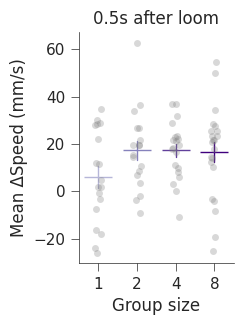

Ns, means, and  sems for data:
1: (N=18) 6.003, 4.637
2: (N=18) 17.298, 3.992
4: (N=20) 17.254, 2.726
8: (N=22) 16.574, 4.166

Normality test (Shapiro-Wilk):
Group 1: W = 0.938, p = 2.6580157297e-01
Group 2: W = 0.946, p = 3.6188110212e-01
Group 4: W = 0.971, p = 7.8453069478e-01
Group 8: W = 0.948, p = 2.8850663682e-01
all groups are normally distributed → use parametric test.

One-way ANOVA:
                 sum_sq    df        F    PR(>F)
C(group)   1686.795169   3.0  1.86596  0.142745
Residual  22298.239086  74.0      NaN       NaN


,1fish,2fish,4fish,8fish
0,34.885624,-2.159309,6.151539,34.181465
1,1.872841,-3.839719,21.611160,23.509433
2,21.978722,21.459213,36.995553,54.676679
3,28.917541,15.386410,8.009918,13.872493
4,1.730150,26.608180,16.686453,20.773509
5,27.929350,14.396588,18.073907,25.341906
6,-16.213517,19.677008,0.111119,-3.367795
7,11.834323,8.374432,23.497331,-4.105672
8,-17.949656,19.640806,19.637041,-19.494399
9,-3.444739,10.698012,11.300857,12.277259


In [10]:
subpanel = 'S1j'
window_of_interest = [0.5]
rng = np.random.default_rng(seed=39)

for woi in window_of_interest:

  group_sizes = [1,2,4,8]; group_values = {n: [] for n in group_sizes}
  hex_colors = ['#b6b6d8', '#8682bc', '#61409b', '#3f007d']

  for exp in experiments[::]:
    load_path = save_path + exp + '/'; output_path = save_path + exp + '/'
    fish_num = metadata.fish_num[exp];
    if fish_num not in group_sizes: continue

    # load data
    data = np.load(load_path + 'lev0_basics.npz', allow_pickle=True)
    fps, scale = data['fps'], data['scale']
    f_speed =  data['f_speed']*scale
    data = np.load(load_path + 'lev0_loom.npz', allow_pickle=True)
    loom_on, loom_len = data['loom_frames'][0], data['loom_len']; loom_off = loom_on + loom_len

    # compare pre and post tap 500-ms
    window = int(fps*woi)

    pre_speeds = [np.nanmean(i[loom_off-int(fps*30):loom_off]) for i in f_speed]
    post_speeds = [i[loom_off:loom_off+window] for i in f_speed]

    # get mean of the group if n>1
    if fish_num == 1:
      group_values[fish_num].append(np.nanmean(post_speeds[0])-np.nanmean(pre_speeds[0]))
    else:
      # randomly pull one from the group
      f = rng.choice(np.arange(fish_num))
      group_values[fish_num].append((np.nanmean(post_speeds[f])-np.nanmean(pre_speeds[f])))

  # plot
  plt.figure(figsize=[2,3])
  sns.stripplot(data=group_values,color='gray',alpha=0.3,size=5)
  sns.pointplot(data=group_values,palette=hex_colors,linestyle="none",marker="_",estimator='mean',errorbar='se',markersize=20,markeredgewidth=1,errwidth=1);
  plt.xlabel('Group size'); plt.ylabel(f'Mean ΔSpeed (mm/s)')
  sns.despine(); plt.title(f'{woi}s after loom')
  print(figure_path+subpanel)
  # plt.savefig(figure_path+subpanel+f".pdf",bbox_inches='tight');
  plt.show()

  # stats
  group_sizes = list(group_values.keys())
  groups = group_values.keys()
  summary_data = group_values.values()
  print("Ns, means, and  sems for data:")
  for id, s in enumerate(summary_data):
    print(f'{group_sizes[id]}: (N={len(s)}) {np.nanmean(s):.3f}, {scipy.stats.sem(s):.3f}')

  ## -- 1. Test for normality in each group -- ##
  print("\nNormality test (Shapiro-Wilk):")
  normality_results = {}
  for group, data in zip(groups, summary_data):
    stat, p = stats.shapiro(data)
    normality_results[group] = {'W': stat, 'p': p}
  for g, res in normality_results.items():
    print(f"Group {g}: W = {res['W']:.3f}, p = {res['p']:.10e}")

  is_normal = all(res['p'] > 0.05 for res in normality_results.values());
  if is_normal: print("all groups are normally distributed \u2192 use parametric test.")
  else: print("not all groups are normally distributed \u2192 use nonparametric test.")

  ## -- 2. Group comparisons (& post hoc test) -- ##
  unique_groups = len(groups);
  if unique_groups == 2:
    groups = list(groups); summary_data = group_values
    #  Two groups: t-test or Mann-Whitney
    if is_normal:
      stat, p = stats.ttest_ind(summary_data[groups[0]], summary_data[groups[1]])
      print(f"\nT-test: t = {stat:.3f}, p = {p:.10e}")
    else:
      stat, p = stats.mannwhitneyu(summary_data[groups[0]], summary_data[groups[1]])
      print(f"\nMann-Whitney U: U = {stat:.3f}, p = {p:.10e}")

  elif unique_groups > 2:
    if is_normal: # One-way ANOVA
      summary_data = list(group_values.values())
      groups = list(group_values.keys())
      df = pd.DataFrame({'data': np.concatenate(summary_data), 'group': np.repeat(groups, [len(d) for d in summary_data])})
      # Define the formula
      formula = 'data ~ C(group)'
      # Fit the model
      model = smf.ols(formula, data=df).fit()
      anova_table = sm.stats.anova_lm(model, typ=2)
      print("\nOne-way ANOVA:\n", anova_table)
      if anova_table['PR(>F)'].loc['C(group)'] < 0.05:
        flat_data = [val for sublist in summary_data for val in sublist]
        groups = [group_names[i] for i, sublist in enumerate(summary_data) for _ in sublist]
        tukey = pairwise_tukeyhsd(endog=flat_data, groups=groups, alpha=0.05)
        print("\nTukey's HSD post hoc test:\n", tukey.summary())
        for res in tukey._results_table.data[1:]:
          g1, g2, p = res[0], res[1], res[4]

    else: # Kruskal-Wallis test
      stat, p = stats.kruskal(*summary_data)
      print(f"\nKruskal-Wallis H-test: H = {stat:.3f}, p = {p:.10e}")
      if p < 0.05:
        # Dunn's post hoc test with Bonferroni correction
        data_for_dunn = list(summary_data); group_for_dunn = list(groups)
        dunn = scikit.posthoc_dunn(data_for_dunn, p_adjust='bonferroni')
        print("\nDunn's post hoc test with bonferroni correction: ",group_for_dunn)
        print(dunn)

  # save source data into csv
  series_dict = {}
  for key, values in group_values.items(): series_dict[f'{key}fish'] = pd.Series(values)

  df = pd.DataFrame(series_dict)
  display(df)
  # df.to_csv(csv_path+subpanel+f'.csv', index=False)

# S1k - baseline speed stats (1248)

/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S1k


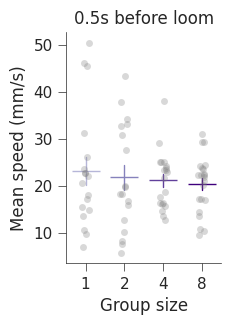

Ns, means, and  sems for data:
1: (N=18) 23.190, 2.995
2: (N=18) 21.818, 2.679
4: (N=20) 21.182, 1.373
8: (N=22) 20.374, 1.288

Normality test (Shapiro-Wilk):
Group 1: W = 0.879, p = 2.4773166902e-02
Group 2: W = 0.943, p = 3.2849400241e-01
Group 4: W = 0.914, p = 7.7195945416e-02
Group 8: W = 0.952, p = 3.4853424008e-01
not all groups are normally distributed → use nonparametric test.

Kruskal-Wallis H-test: H = 0.093, p = 9.9267713069e-01


,1fish,2fish,4fish,8fish
0,15.567419,10.060390,18.743334,9.581456
1,9.735652,7.611882,16.215640,10.760613
2,22.082639,8.297462,16.326556,10.270400
3,23.568630,5.725947,17.557288,17.233513
4,18.008331,15.811847,21.587715,14.519118
5,6.932318,18.163993,25.005803,13.666187
6,45.520135,19.776438,25.077014,29.416214
7,22.632085,18.173830,23.890537,29.233600
8,50.500253,20.044260,23.415553,21.772222
9,22.652431,12.746394,23.399922,22.277087


In [ ]:
subpanel = 'S1k'
window_of_interest = [0.5]

for woi in window_of_interest:

  group_sizes = [1,2,4,8]; group_values = {n: [] for n in group_sizes}
  hex_colors = ['#b6b6d8', '#8682bc', '#61409b', '#3f007d']

  for exp in experiments[:98:]:
    load_path = save_path + exp + '/'; output_path = save_path + exp + '/'
    fish_num = metadata.fish_num[exp];
    if fish_num not in group_sizes: continue

    # load data
    data = np.load(load_path + 'lev0_basics.npz', allow_pickle=True)
    fps, scale = data['fps'], data['scale']
    f_speed =  data['f_speed']*scale
    data = np.load(load_path + 'lev0_loom.npz', allow_pickle=True)
    loom_on, loom_len = data['loom_frames'][0], data['loom_len']; loom_off = loom_on + loom_len

    # compare pre and post tap 500-ms
    window = int(fps*woi)

    pre_speeds = [np.random.choice(i[:loom_off], size=window, replace=False) for i in f_speed]
    post_speeds = [i[loom_off:loom_off+window] for i in f_speed]

    # get mean of the group if n>1
    if fish_num == 1:
      group_values[fish_num].append(np.nanmean(pre_speeds[0]))
    else:
      group_values[fish_num].append(np.mean([(np.nanmean(pre_speeds[f])) for f in range(fish_num)]))

  # plot
  plt.figure(figsize=[2,3])
  sns.stripplot(data=group_values,color='gray',alpha=0.3,size=5)
  sns.pointplot(data=group_values,palette=hex_colors,linestyle="none",marker="_",estimator='mean',errorbar='se',markersize=20,markeredgewidth=1,errwidth=1);
  plt.xlabel('Group size'); plt.ylabel(f'Mean speed (mm/s)')
  sns.despine(); plt.title(f'{woi}s before loom')
  print(figure_path+subpanel)
  plt.savefig(figure_path+subpanel+f".pdf",bbox_inches='tight');
  plt.show()

  # stats
  group_sizes = list(group_values.keys())
  groups = group_values.keys()
  summary_data = group_values.values()
  print("Ns, means, and  sems for data:")
  for id, s in enumerate(summary_data):
    print(f'{group_sizes[id]}: (N={len(s)}) {np.nanmean(s):.3f}, {scipy.stats.sem(s):.3f}')

  ## -- 1. Test for normality in each group -- ##
  print("\nNormality test (Shapiro-Wilk):")
  normality_results = {}
  for group, data in zip(groups, summary_data):
    stat, p = stats.shapiro(data)
    normality_results[group] = {'W': stat, 'p': p}
  for g, res in normality_results.items():
    print(f"Group {g}: W = {res['W']:.3f}, p = {res['p']:.10e}")

  is_normal = all(res['p'] > 0.05 for res in normality_results.values());
  if is_normal: print("all groups are normally distributed \u2192 use parametric test.")
  else: print("not all groups are normally distributed \u2192 use nonparametric test.")

  ## -- 2. Group comparisons (& post hoc test) -- ##
  unique_groups = len(groups);
  if unique_groups == 2:
    groups = list(groups); summary_data = group_values
    #  Two groups: t-test or Mann-Whitney
    if is_normal:
      stat, p = stats.ttest_ind(summary_data[groups[0]], summary_data[groups[1]])
      print(f"\nT-test: t = {stat:.3f}, p = {p:.10e}")
    else:
      stat, p = stats.mannwhitneyu(summary_data[groups[0]], summary_data[groups[1]])
      print(f"\nMann-Whitney U: U = {stat:.3f}, p = {p:.10e}")

  elif unique_groups > 2:
    if is_normal: # One-way ANOVA
      summary_data = list(group_values.values())
      groups = list(group_values.keys())
      df = pd.DataFrame({'data': np.concatenate(summary_data), 'group': np.repeat(groups, [len(d) for d in summary_data])})
      # Define the formula
      formula = 'data ~ group'
      # Fit the model
      model = smf.ols(formula, data=df).fit()
      anova_table = sm.stats.anova_lm(model, typ=2)
      print("\nOne-way ANOVA:\n", anova_table)
      if anova_table['PR(>F)'][0] < 0.05:
        flat_data = [val for sublist in summary_data for val in sublist]
        groups = [group_names[i] for i, sublist in enumerate(summary_data) for _ in sublist]
        tukey = pairwise_tukeyhsd(endog=flat_data, groups=groups, alpha=0.05)
        print("\nTukey's HSD post hoc test:\n", tukey.summary())
        for res in tukey._results_table.data[1:]:
          g1, g2, p = res[0], res[1], res[4]

    else: # Kruskal-Wallis test
      stat, p = stats.kruskal(*summary_data)
      print(f"\nKruskal-Wallis H-test: H = {stat:.3f}, p = {p:.10e}")
      if p < 0.05:
        # Dunn's post hoc test with Bonferroni correction
        data_for_dunn = list(summary_data); group_for_dunn = list(groups)
        dunn = scikit.posthoc_dunn(data_for_dunn, p_adjust='bonferroni')
        print("\nDunn's post hoc test with bonferroni correction: ",group_for_dunn)
        print(dunn)

  # save source data into csv
  series_dict = {}
  for key, values in group_values.items(): series_dict[f'{key}fish'] = pd.Series(values)

  df = pd.DataFrame(series_dict)
  display(df)
  df.to_csv(csv_path+subpanel+f'.csv', index=False)

# S1l - travel dist stats (1248)

/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S1l


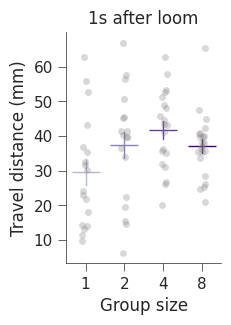

Ns, means, and  sems for data:
1: (N=18) 29.552, 3.767
2: (N=18) 37.450, 3.849
4: (N=20) 41.830, 2.531
8: (N=22) 37.125, 1.983

Normality test (Shapiro-Wilk):
Group 1: W = 0.927, p = 1.7135254121e-01
Group 2: W = 0.959, p = 5.8536784358e-01
Group 4: W = 0.985, p = 9.8303459310e-01
Group 8: W = 0.902, p = 3.2463368812e-02
not all groups are normally distributed → use nonparametric test.

Kruskal-Wallis H-test: H = 8.810, p = 3.1929387466e-02

Dunn's post hoc test with bonferroni correction:  [1, 2, 4, 8]
          1         2        3         4
1  1.000000  0.267926  0.02202  0.562402
2  0.267926  1.000000  1.00000  1.000000
3  0.022020  1.000000  1.00000  1.000000
4  0.562402  1.000000  1.00000  1.000000


,1fish,2fish,4fish,8fish
0,36.961107,6.345671,44.774410,40.512346
1,11.497850,14.572397,26.122215,37.179713
2,35.503737,15.419112,43.498260,35.520976
3,62.784449,45.516970,31.920387,26.209791
4,18.235538,41.542357,26.766992,65.505294
5,21.929416,41.334051,43.196806,36.462956
6,32.643109,39.772854,57.924947,35.426954
7,30.333465,22.293202,45.675317,20.907223
8,31.580625,36.701956,48.980590,24.842037
9,13.996310,39.877255,35.699201,42.284723


In [ ]:
subpanel = 'S1l'
window_of_interest = [1]

for woi in window_of_interest:

  group_sizes = [1,2,4,8]; group_values = {n: [] for n in group_sizes}
  hex_colors = ['#b6b6d8', '#8682bc', '#61409b', '#3f007d']

  for exp in experiments[::]:
    load_path = save_path + exp + '/'; output_path = save_path + exp + '/'
    fish_num = metadata.fish_num[exp];
    if fish_num ==6: continue

    # load data
    data = np.load(load_path + 'lev0_basics.npz', allow_pickle=True)
    fps, scale = data['fps'], data['scale']
    f_speed =  data['f_speed']*scale
    data = np.load(load_path + 'lev0_loom.npz', allow_pickle=True)
    loom_on, loom_len = data['loom_frames'][0], data['loom_len']; loom_off = loom_on + loom_len

    # compare pre and post loom_off 500-ms
    window = int(fps*woi); dt = 1/fps
    f_travel = [np.trapezoid(sp[loom_off:loom_off+window],dx=dt) for sp in f_speed]

    # take mean of the group if >1 fish
    if fish_num == 1:
      group_values[fish_num].append(f_travel[0])
    else:
      group_values[fish_num].append(np.mean([f_travel[f] for f in range(fish_num)]))

  # plot
  plt.figure(figsize=[2,3])
  sns.stripplot(data=group_values,color='gray',alpha=0.3,size=5) #,legend=group_values.keys());
  sns.pointplot(data=group_values,palette=hex_colors,linestyle="none",marker="_",estimator='mean',errorbar='se',markersize=20,markeredgewidth=1,errwidth=1);
  plt.xlabel('Group size'); plt.ylabel('Travel distance (mm)')
  sns.despine(); plt.title(f'{woi}s after loom')
  print(figure_path+subpanel)
  plt.savefig(figure_path+subpanel+f".pdf",bbox_inches='tight');
  plt.show()

  # stats
  group_sizes = list(group_values.keys())
  groups = group_values.keys()
  summary_data = group_values.values()
  print("Ns, means, and  sems for data:")
  for id, s in enumerate(summary_data):
    print(f'{group_sizes[id]}: (N={len(s)}) {np.nanmean(s):.3f}, {scipy.stats.sem(s):.3f}')

  ## -- 1. Test for normality in each group -- ##
  print("\nNormality test (Shapiro-Wilk):")
  normality_results = {}
  for group, data in zip(groups, summary_data):
    stat, p = stats.shapiro(data)
    normality_results[group] = {'W': stat, 'p': p}
  for g, res in normality_results.items():
    print(f"Group {g}: W = {res['W']:.3f}, p = {res['p']:.10e}")

  is_normal = all(res['p'] > 0.05 for res in normality_results.values());
  if is_normal: print("all groups are normally distributed \u2192 use parametric test.")
  else: print("not all groups are normally distributed \u2192 use nonparametric test.")

  ## -- 2. Group comparisons (& post hoc test) -- ##
  unique_groups = len(groups);
  if unique_groups == 2:
    groups = list(groups); summary_data = group_values
    #  Two groups: t-test or Mann-Whitney
    if is_normal:
      stat, p = stats.ttest_ind(summary_data[groups[0]], summary_data[groups[1]])
      print(f"\nT-test: t = {stat:.3f}, p = {p:.10e}")
    else:
      stat, p = stats.mannwhitneyu(summary_data[groups[0]], summary_data[groups[1]])
      print(f"\nMann-Whitney U: U = {stat:.3f}, p = {p:.10e}")

  elif unique_groups > 2:
    if is_normal: # One-way ANOVA
      summary_data = list(group_values.values())
      groups = list(group_values.keys())
      df = pd.DataFrame({'data': np.concatenate(summary_data), 'group': np.repeat(groups, [len(d) for d in summary_data])})
      # Define the formula
      formula = 'data ~ group'
      # Fit the model
      model = smf.ols(formula, data=df).fit()
      anova_table = sm.stats.anova_lm(model, typ=2)
      print("\nOne-way ANOVA:\n", anova_table)
      if anova_table['PR(>F)'][0] < 0.05:
        flat_data = [val for sublist in summary_data for val in sublist]
        groups = [group_names[i] for i, sublist in enumerate(summary_data) for _ in sublist]
        tukey = pairwise_tukeyhsd(endog=flat_data, groups=groups, alpha=0.05)
        print("\nTukey's HSD post hoc test:\n", tukey.summary())
        for res in tukey._results_table.data[1:]:
          g1, g2, p = res[0], res[1], res[4]

    else: # Kruskal-Wallis test
      stat, p = stats.kruskal(*summary_data)
      print(f"\nKruskal-Wallis H-test: H = {stat:.3f}, p = {p:.10e}")
      if p < 0.05:
        # Dunn's post hoc test with Bonferroni correction
        data_for_dunn = list(summary_data); group_for_dunn = list(groups)
        dunn = scikit.posthoc_dunn(data_for_dunn, p_adjust='bonferroni')
        print("\nDunn's post hoc test with bonferroni correction: ",group_for_dunn)
        print(dunn)

  # save source data into csv
  series_dict = {}
  for key, values in group_values.items(): series_dict[f'{key}fish'] = pd.Series(values)

  df = pd.DataFrame(series_dict)
  display(df)
  df.to_csv(csv_path+subpanel+f'.csv', index=False)

# S1m - baseline travel dist stats (1248)

/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S1m


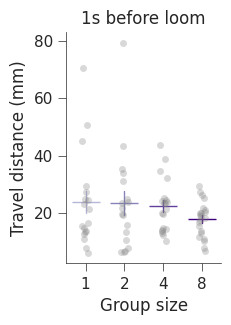

Ns, means, and  sems for data:
1: (N=18) 23.935, 3.903
2: (N=18) 23.634, 4.145
4: (N=20) 22.492, 2.049
8: (N=22) 17.969, 1.321

Normality test (Shapiro-Wilk):
Group 1: W = 0.830, p = 4.1555834239e-03
Group 2: W = 0.817, p = 2.6630178544e-03
Group 4: W = 0.919, p = 9.4774516141e-02
Group 8: W = 0.975, p = 8.2565956112e-01
not all groups are normally distributed → use nonparametric test.

Kruskal-Wallis H-test: H = 1.928, p = 5.8742820732e-01


,1fish,2fish,4fish,8fish
0,15.722663,6.680797,14.220373,6.897259
1,8.081797,13.540265,13.835380,19.483815
2,25.101791,6.552081,13.336274,8.116401
3,29.579285,6.897886,12.395020,10.938231
4,24.727904,10.840330,32.256654,18.415273
5,6.323732,15.900907,21.367737,10.383421
6,50.817204,19.783156,24.368267,26.555830
7,21.634555,24.963653,23.946444,29.471257
8,70.512285,23.774352,20.148113,11.670499
9,13.365445,7.978167,19.647435,20.151830


In [ ]:
subpanel = 'S1m'
window_of_interest = [1]

for woi in window_of_interest:

  group_sizes = [1,2,4,8]; group_values = {n: [] for n in group_sizes}
  hex_colors = ['#b6b6d8', '#8682bc', '#61409b', '#3f007d']

  for exp in experiments[::]:
    load_path = save_path + exp + '/'; output_path = save_path + exp + '/'
    fish_num = metadata.fish_num[exp];
    if fish_num not in group_sizes: continue

    # load data
    data = np.load(load_path + 'lev0_basics.npz', allow_pickle=True)
    fps, scale = data['fps'], data['scale']
    f_speed =  data['f_speed']*scale
    data = np.load(load_path + 'lev0_loom.npz', allow_pickle=True)
    loom_on, loom_len = data['loom_frames'][0], data['loom_len']; loom_off = loom_on + loom_len

    # compare pre and post loom_off 500-ms
    window = int(fps*woi); dt = 1/fps
    f_travel = [np.trapezoid(sp[loom_on-window:loom_on],dx=dt) for sp in f_speed]

    # take mean of the group if >1 fish
    if fish_num == 1:
      group_values[fish_num].append(f_travel[0])
    else:
      group_values[fish_num].append(np.mean([f_travel[f] for f in range(fish_num)]))

  # plot
  plt.figure(figsize=[2,3])
  sns.stripplot(data=group_values,color='gray',alpha=0.3,size=5)
  sns.pointplot(data=group_values,palette=hex_colors,linestyle="none",marker="_",estimator='mean',errorbar='se',markersize=20,markeredgewidth=1,errwidth=1);
  plt.xlabel('Group size'); plt.ylabel('Travel distance (mm)')
  sns.despine(); plt.title(f'{woi}s before loom')
  print(figure_path+subpanel)
  plt.savefig(figure_path+subpanel+f".pdf",bbox_inches='tight');
  plt.show()

  # stats
  group_sizes = list(group_values.keys())
  groups = group_values.keys()
  summary_data = group_values.values()
  print("Ns, means, and  sems for data:")
  for id, s in enumerate(summary_data):
    print(f'{group_sizes[id]}: (N={len(s)}) {np.nanmean(s):.3f}, {scipy.stats.sem(s):.3f}')

  ## -- 1. Test for normality in each group -- ##
  print("\nNormality test (Shapiro-Wilk):")
  normality_results = {}
  for group, data in zip(groups, summary_data):
    stat, p = stats.shapiro(data)
    normality_results[group] = {'W': stat, 'p': p}
  for g, res in normality_results.items():
    print(f"Group {g}: W = {res['W']:.3f}, p = {res['p']:.10e}")

  is_normal = all(res['p'] > 0.05 for res in normality_results.values());
  if is_normal: print("all groups are normally distributed \u2192 use parametric test.")
  else: print("not all groups are normally distributed \u2192 use nonparametric test.")

  ## -- 2. Group comparisons (& post hoc test) -- ##
  unique_groups = len(groups);
  if unique_groups == 2:
    groups = list(groups); summary_data = group_values
    #  Two groups: t-test or Mann-Whitney
    if is_normal:
      stat, p = stats.ttest_ind(summary_data[groups[0]], summary_data[groups[1]])
      print(f"\nT-test: t = {stat:.3f}, p = {p:.10e}")
    else:
      stat, p = stats.mannwhitneyu(summary_data[groups[0]], summary_data[groups[1]])
      print(f"\nMann-Whitney U: U = {stat:.3f}, p = {p:.10e}")

  elif unique_groups > 2:
    if is_normal: # One-way ANOVA
      summary_data = list(group_values.values())
      groups = list(group_values.keys())
      df = pd.DataFrame({'data': np.concatenate(summary_data), 'group': np.repeat(groups, [len(d) for d in summary_data])})
      # Define the formula
      formula = 'data ~ group'
      # Fit the model
      model = smf.ols(formula, data=df).fit()
      anova_table = sm.stats.anova_lm(model, typ=2)
      print("\nOne-way ANOVA:\n", anova_table)
      if anova_table['PR(>F)'][0] < 0.05:
        flat_data = [val for sublist in summary_data for val in sublist]
        groups = [group_names[i] for i, sublist in enumerate(summary_data) for _ in sublist]
        tukey = pairwise_tukeyhsd(endog=flat_data, groups=groups, alpha=0.05)
        print("\nTukey's HSD post hoc test:\n", tukey.summary())
        for res in tukey._results_table.data[1:]:
          g1, g2, p = res[0], res[1], res[4]

    else: # Kruskal-Wallis test
      stat, p = stats.kruskal(*summary_data)
      print(f"\nKruskal-Wallis H-test: H = {stat:.3f}, p = {p:.10e}")
      if p < 0.05:
        # Dunn's post hoc test with Bonferroni correction
        data_for_dunn = list(summary_data); group_for_dunn = list(groups)
        dunn = scikit.posthoc_dunn(data_for_dunn, p_adjust='bonferroni')
        print("\nDunn's post hoc test with bonferroni correction: ",group_for_dunn)
        print(dunn)

  # save source data into csv
  series_dict = {}
  for key, values in group_values.items(): series_dict[f'{key}fish'] = pd.Series(values)

  df = pd.DataFrame(series_dict)
  display(df)
  df.to_csv(csv_path+subpanel+f'.csv', index=False)

# S1n - turning PDF (+inset)

/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S1n - full


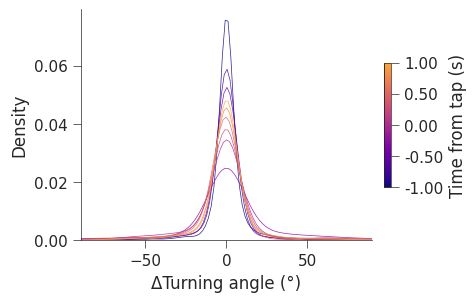

/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S1n - inset


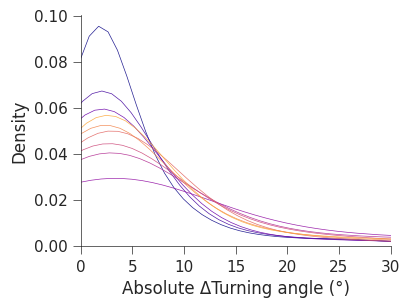

,-1.00s,-0.75s,-0.50s,-0.25s,0.00s,0.25s,0.50s,0.75s,1.00s
0,-11.975982,34.808464,-3.190930,-0.064098,-12.891107,-1.885248,-9.844747,-8.764146,-14.292832
1,-11.042829,25.716028,-3.060621,-0.037069,-10.397313,-0.209581,-10.820747,-9.103055,-17.324060
2,-8.633407,16.433442,-3.452649,0.300299,-8.585366,0.874476,-12.630453,-8.578034,-18.334337
3,-5.691067,9.419481,-4.399450,0.904916,-6.803862,1.476358,-15.256226,-7.228931,-16.980635
4,-3.339278,5.035031,-6.076291,1.766957,-3.972789,1.913881,-17.278778,-5.220528,-13.988128
...,...,...,...,...,...,...,...,...,...
1995,4.033009,NaN,NaN,NaN,NaN,NaN,NaN,-0.560159,NaN
1996,2.513773,NaN,NaN,NaN,NaN,NaN,NaN,1.204239,NaN
1997,0.156517,NaN,NaN,NaN,NaN,NaN,NaN,3.395168,NaN
1998,-2.354366,NaN,NaN,NaN,NaN,NaN,NaN,4.779414,NaN


In [ ]:
# 250 ms interval
group_sizes = [4]; group_values = {n: [] for n in group_sizes}
hex_colors = ['#61409b']

dt_sec = 0.05  # sampling interval for delta heading
fps = 121      # frames per second (adjust as needed)

# stimulus-relative windows (in sec)
window_times = {f'{i:.2f}s':(i,i+0.25) for i in np.arange(-1,1.25,0.25)}

# prepare pooling structure
pooled_dtheta = {g: {w: [] for w in window_times} for g in group_sizes}

for exp in experiments:
  load_path = save_path + exp + '/'
  fish_num = metadata.fish_num[exp]
  if fish_num not in group_sizes: continue

  # load heading data
  data = np.load(load_path + 'lev0_basics.npz', allow_pickle=True)
  f_heading = data['f_heading']  # shape: fish_num x frame_num

  # load stimulus frame
  data = np.load(load_path + 'lev0_loom.npz', allow_pickle=True)
  loom_on, loom_len = data['loom_frames'][0], data['loom_len']; loom_off = loom_on + loom_len
  loom_frame = loom_off

  # convert delta_t to frames
  dt = int(np.round(dt_sec * fps))

  # loop over windows
  for w_name, (t_start, t_end) in window_times.items():
    # compute start and stop frame indices relative to tap
    i0 = loom_frame + int(t_start * fps)
    i1 = loom_frame + int(t_end * fps)

    # collect |Δθ| for all fish in this experiment
    for f in range(fish_num):
      theta = f_heading[f, i0:i1]
      if len(theta) <= dt: continue
      # wrapped delta heading in degrees
      dtheta = (theta[dt:] - theta[:-dt] + 180) % 360 - 180
      pooled_dtheta[fish_num][w_name].append(dtheta)

    if not pooled_dtheta[fish_num][w_name]: continue
    all_dtheta = np.concatenate(pooled_dtheta[fish_num][w_name]);
    all_abs_dtheta = np.concatenate(np.abs(pooled_dtheta[fish_num][w_name]))

# after looping over all experiments, concatenate samples across experiments/fish
for g in pooled_dtheta:
  for w_name, _ in window_times.items():
    if pooled_dtheta[g][w_name]:  # avoid empty lists
      pooled_dtheta[g][w_name] = np.concatenate(pooled_dtheta[g][w_name])
    else:
      pooled_dtheta[g][w_name] = np.array([])

# map window index to a continuous scale
window_list = list(window_times.keys())
n_w = len(window_list)
norm = mpl.colors.Normalize(vmin=0, vmax=n_w-1)
original_cmap = plt.get_cmap('plasma')
colors = original_cmap(np.linspace(0, 0.8, 256))
cmap = mcolors.ListedColormap(colors)

# PLOTTING
# pdf
subpanel = 'S1n - full'

plt.figure(figsize=(4,3))
g = group_sizes[0]
for iw, w_name in enumerate(window_list):
  data = pooled_dtheta[g][w_name]
  if len(data) == 0: continue
  color = cmap(norm(iw))
  sns.kdeplot(data, fill=False, c=color, alpha=0.9, bw_method=None, bw_adjust=1, cut=1, lw=0.5)

sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gcf().axes, fraction=0.02, pad=0.04)
tick_locs = np.linspace(0, n_w-1, 5)
tick_labels = [f"{list(window_times.values())[int(i)][0]:.2f}" for i in tick_locs]

cbar.set_ticks(tick_locs); cbar.set_ticklabels(tick_labels); cbar.set_label('Time from tap (s)')
plt.xlabel('ΔTurning angle (°)'); plt.ylabel('Density'); plt.xlim(-90,90)
sns.despine();
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+f".pdf",bbox_inches='tight');
plt.show()

# inset
subpanel = 'S1n - inset'

plt.figure(figsize=(4,3))
g = group_sizes[0]
for iw, w_name in enumerate(window_list):
  data = np.abs(pooled_dtheta[g][w_name])
  if len(data) == 0: continue
  color = cmap(norm(iw))
  sns.kdeplot(data, fill=False, c=color, alpha=0.9, bw_method=None, bw_adjust=1, cut=1, lw=0.5)

plt.xlabel('Absolute ΔTurning angle (°)'); plt.ylabel('Density'); plt.xlim(0,30); sns.despine()
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+f".pdf",bbox_inches='tight');
plt.show()

# save source data into csv
series_dict = {}
for iw, w_name in enumerate(window_times):
  data = pooled_dtheta[g][w_name]
  col_name = f"{w_name}"
  series_dict[col_name] = pd.Series(data)

df = pd.DataFrame(series_dict)
display(df)
subpanel = 'S1n'
df.to_csv(csv_path+subpanel+'.csv', index=False)

/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S1n - full (rebuttal)


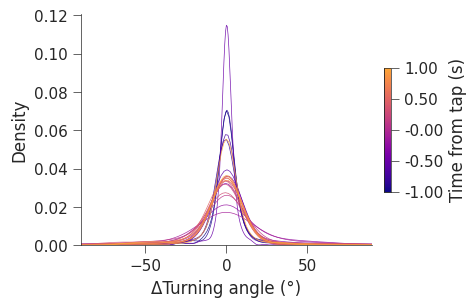

/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S1n - inset (rebuttal)


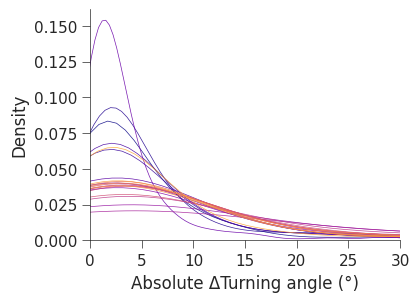

,-1.00s,-0.90s,-0.80s,-0.70s,-0.60s,-0.50s,-0.40s,-0.30s,-0.20s,-0.10s,...,0.10s,0.20s,0.30s,0.40s,0.50s,0.60s,0.70s,0.80s,0.90s,1.00s
0,-11.975982,5.668945,24.266656,1.007286,2.261244,-3.190930,-1.130140,3.924974,3.039974,28.374194,...,1.379922,-0.332863,0.617686,-2.656515,-9.844747,9.075916,5.996744,-2.613246,1.270630,-10.856739
1,-11.042829,8.220817,33.093822,0.732027,2.299960,-3.060621,1.018149,3.187295,3.346282,32.790421,...,-1.053180,-2.987174,-0.583258,-2.504509,-10.820747,9.982519,5.050110,-2.403865,2.003182,-14.292832
2,-8.633407,10.163405,41.268050,0.126129,1.987485,-3.452649,2.972679,2.489800,3.088600,32.199803,...,-3.321141,-4.477906,-1.315428,-2.109469,-12.630453,8.784690,2.814017,-2.623894,1.971559,-17.324060
3,-5.691067,10.785952,45.998292,-0.628682,1.445970,-4.399450,4.724545,1.571786,2.214062,26.407588,...,-4.614646,-4.592902,-1.406900,-2.062449,-15.256226,6.120515,0.057796,-3.161216,1.456251,-18.334337
4,-3.339278,10.060553,46.077566,-1.382929,1.061280,-6.076291,5.480248,0.755763,0.935462,16.586800,...,-4.648828,-4.157927,-1.355583,-2.958264,-17.278778,2.699209,-3.393830,-3.987840,0.697951,-16.980635
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
555,-1.399908,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.861653
556,-0.890136,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.829286
557,-0.157886,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.238858
558,0.747045,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.019546


In [ ]:
# 100 ms interval
group_sizes = [4]; group_values = {n: [] for n in group_sizes}
hex_colors = ['#61409b']

dt_sec = 0.05  # sampling interval for delta heading
fps = 121      # frames per second (adjust as needed)

# stimulus-relative windows (in sec)
window_times = {f'{i:.2f}s':(i,i+0.1) for i in np.arange(-1,1.1,0.1)}

# prepare pooling structure
pooled_dtheta = {g: {w: [] for w in window_times} for g in group_sizes}

for exp in experiments:
  load_path = save_path + exp + '/'
  fish_num = metadata.fish_num[exp]
  if fish_num not in group_sizes: continue

  # load heading data
  data = np.load(load_path + 'lev0_basics.npz', allow_pickle=True)
  f_heading = data['f_heading']  # shape: fish_num x frame_num

  # load stimulus frame
  data = np.load(load_path + 'lev0_loom.npz', allow_pickle=True)
  loom_on, loom_len = data['loom_frames'][0], data['loom_len']; loom_off = loom_on + loom_len
  loom_frame = loom_off

  # convert delta_t to frames
  dt = int(np.round(dt_sec * fps))

  # loop over windows
  for w_name, (t_start, t_end) in window_times.items():
    # compute start and stop frame indices relative to tap
    i0 = loom_frame + int(t_start * fps)
    i1 = loom_frame + int(t_end * fps)

    # collect |Δθ| for all fish in this experiment
    for f in range(fish_num):
      theta = f_heading[f, i0:i1]
      if len(theta) <= dt: continue
      # wrapped delta heading in degrees
      dtheta = (theta[dt:] - theta[:-dt] + 180) % 360 - 180
      pooled_dtheta[fish_num][w_name].append(dtheta)

    if not pooled_dtheta[fish_num][w_name]: continue
    all_dtheta = np.concatenate(pooled_dtheta[fish_num][w_name]);
    all_abs_dtheta = np.concatenate(np.abs(pooled_dtheta[fish_num][w_name]))

# after looping over all experiments, concatenate samples across experiments/fish
for g in pooled_dtheta:
  for w_name, _ in window_times.items():
    if pooled_dtheta[g][w_name]:  # avoid empty lists
      pooled_dtheta[g][w_name] = np.concatenate(pooled_dtheta[g][w_name])
    else:
      pooled_dtheta[g][w_name] = np.array([])

# map window index to a continuous scale
window_list = list(window_times.keys())
n_w = len(window_list)
norm = mpl.colors.Normalize(vmin=0, vmax=n_w-1)
original_cmap = plt.get_cmap('plasma')
colors = original_cmap(np.linspace(0, 0.8, 256))
cmap = mcolors.ListedColormap(colors)

# PLOTTING
# pdf
subpanel = 'S1n - full (rebuttal)'

plt.figure(figsize=(4,3))
g = group_sizes[0]
for iw, w_name in enumerate(window_list):
  data = pooled_dtheta[g][w_name]
  if len(data) == 0: continue
  color = cmap(norm(iw))
  sns.kdeplot(data, fill=False, c=color, alpha=0.9, bw_method=None, bw_adjust=1, cut=1, lw=0.5)

sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gcf().axes, fraction=0.02, pad=0.04)
tick_locs = np.linspace(0, n_w-1, 5)
tick_labels = [f"{list(window_times.values())[int(i)][0]:.2f}" for i in tick_locs]

cbar.set_ticks(tick_locs); cbar.set_ticklabels(tick_labels); cbar.set_label('Time from tap (s)')
plt.xlabel('ΔTurning angle (°)'); plt.ylabel('Density'); plt.xlim(-90,90)
sns.despine();
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+f".pdf",bbox_inches='tight');
plt.show()

# inset
subpanel = 'S1n - inset (rebuttal)'

plt.figure(figsize=(4,3))
g = group_sizes[0]
for iw, w_name in enumerate(window_list):
  data = np.abs(pooled_dtheta[g][w_name])
  if len(data) == 0: continue
  color = cmap(norm(iw))
  sns.kdeplot(data, fill=False, c=color, alpha=0.9, bw_method=None, bw_adjust=1, cut=1, lw=0.5)

plt.xlabel('Absolute ΔTurning angle (°)'); plt.ylabel('Density'); plt.xlim(0,30); sns.despine()
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+f".pdf",bbox_inches='tight');
plt.show()

# save source data into csv
series_dict = {}
for iw, w_name in enumerate(window_times):
  data = pooled_dtheta[g][w_name]
  col_name = f"{w_name}"
  series_dict[col_name] = pd.Series(data)

df = pd.DataFrame(series_dict)
display(df)
subpanel = 'S1n (rebuttal)'
df.to_csv(csv_path+subpanel+'.csv', index=False)

# S1o - turning CDF

In [ ]:
group_sizes = [4]; group_values = {n: [] for n in group_sizes}
hex_colors = ['#61409b']

dt_sec = 0.05  # sampling interval for delta heading
fps = 121      # frames per second (adjust as needed)

# stimulus-relative windows (in sec)
window_times = {f'{i:.2f}s':(i,i+0.25) for i in np.arange(-1,1.25,0.25)}

# prepare pooling structure
pooled_dtheta = {g: {w: [] for w in window_times} for g in group_sizes}
metrics = {g: {w: [] for w in window_times} for g in group_sizes}

for exp in experiments:
  load_path = save_path + exp + '/'
  fish_num = metadata.fish_num[exp]
  if fish_num not in group_sizes: continue

  # load heading data
  data = np.load(load_path + 'lev0_basics.npz', allow_pickle=True)
  f_heading = data['f_heading']  # shape: fish_num x frame_num

  # load stimulus frame
  data = np.load(load_path + 'lev0_loom.npz', allow_pickle=True)
  loom_on, loom_len = data['loom_frames'][0], data['loom_len']; loom_off = loom_on + loom_len
  loom_frame = loom_off

  # convert delta_t to frames
  dt = int(np.round(dt_sec * fps))
  # per-experiment metrics container
  metrics_exp = {w: {'iqr': [], 'p90': [], 'exp': exp} for w in window_times}

  # loop over windows
  for w_name, (t_start, t_end) in window_times.items():
    # compute start and stop frame indices relative to tap
    i0 = loom_frame + int(t_start * fps)
    i1 = loom_frame + int(t_end * fps)

    # collect |Δθ| for all fish in this experiment
    for f in range(fish_num):
      theta = f_heading[f, i0:i1]
      if len(theta) <= dt: continue
      # # wrapped delta heading in degrees
      dtheta = (theta[dt:] - theta[:-dt] + 180) % 360 - 180
      # abs_dtheta = np.abs(dtheta)
      pooled_dtheta[fish_num][w_name].append(dtheta)

    if not pooled_dtheta[fish_num][w_name]: continue
    all_dtheta = np.concatenate(pooled_dtheta[fish_num][w_name]);
    all_abs_dtheta = np.concatenate(np.abs(pooled_dtheta[fish_num][w_name]))
    # compute metrics
    metrics_exp[w_name]['iqr'] = np.percentile(all_dtheta, 75) - np.percentile(all_dtheta, 25)
    metrics_exp[w_name]['p90'] = np.percentile(all_abs_dtheta, 90)

  # append per experiment metrics to group-level
  for w_name in window_times:
    metrics[fish_num][w_name].append(metrics_exp[w_name])

# after looping over all experiments, concatenate samples across experiments/fish
for g in pooled_dtheta:
  for w_name, _ in window_times.items():
    if pooled_dtheta[g][w_name]:  # avoid empty lists
      pooled_dtheta[g][w_name] = np.concatenate(pooled_dtheta[g][w_name])
    else:
      pooled_dtheta[g][w_name] = np.array([])

# map window index to a continuous scale
window_list = list(window_times.keys())
n_w = len(window_list)
norm = mpl.colors.Normalize(vmin=0, vmax=n_w-1)
original_cmap = plt.get_cmap('plasma')
colors = original_cmap(np.linspace(0, 0.8, 256))
cmap = mcolors.ListedColormap(colors)

/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v8/subpanels/S1o


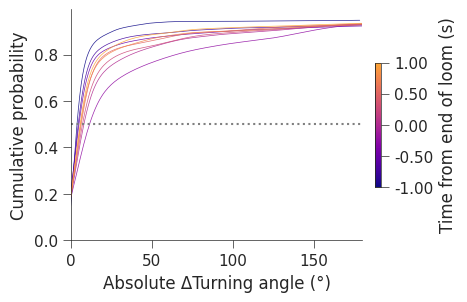

,-1.00s,-0.75s,-0.50s,-0.25s,0.00s,0.25s,0.50s,0.75s,1.00s
0,-11.975982,34.808464,-3.190930,-0.064098,-12.891107,-1.885248,-9.844747,-8.764146,-14.292832
1,-11.042829,25.716028,-3.060621,-0.037069,-10.397313,-0.209581,-10.820747,-9.103055,-17.324060
2,-8.633407,16.433442,-3.452649,0.300299,-8.585366,0.874476,-12.630453,-8.578034,-18.334337
3,-5.691067,9.419481,-4.399450,0.904916,-6.803862,1.476358,-15.256226,-7.228931,-16.980635
4,-3.339278,5.035031,-6.076291,1.766957,-3.972789,1.913881,-17.278778,-5.220528,-13.988128
...,...,...,...,...,...,...,...,...,...
1995,4.033009,NaN,NaN,NaN,NaN,NaN,NaN,-0.560159,NaN
1996,2.513773,NaN,NaN,NaN,NaN,NaN,NaN,1.204239,NaN
1997,0.156517,NaN,NaN,NaN,NaN,NaN,NaN,3.395168,NaN
1998,-2.354366,NaN,NaN,NaN,NaN,NaN,NaN,4.779414,NaN


In [ ]:
from scipy.special import ndtr
from scipy.stats import gaussian_kde

# cdf - use abs values
plt.figure(figsize=(4,3))
g = group_sizes[0]
for iw, w_name in enumerate(window_list):
  data = np.abs(pooled_dtheta[g][w_name])
  if len(data) == 0: continue
  color = cmap(norm(iw))
  sns.kdeplot(data, fill=False, c=color, alpha=0.9, cumulative=True, cut=1, lw=0.5)
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # required for older matplotlib versions

cbar = plt.colorbar(sm, ax=plt.gcf().axes, fraction=0.02, pad=0.04)
tick_locs = np.linspace(0, n_w-1, 5)
tick_labels = [f"{list(window_times.values())[int(i)][0]:.2f}" for i in tick_locs]

cbar.set_ticks(tick_locs); cbar.set_ticklabels(tick_labels); cbar.set_label('Time from end of loom (s)')
plt.xlabel('Absolute ΔTurning angle (°)'); plt.ylabel('Cumulative probability')
plt.xlim(0,180); plt.axhline(0.5,ls=':',color='grey')
sns.despine();
subpanel = 'S1o'
print(figure_path+subpanel)
# plt.savefig(figure_path+subpanel+f".pdf",bbox_inches='tight');
plt.show()

# save source data into csv
series_dict = {}
for iw, w_name in enumerate(window_times):
  data = pooled_dtheta[g][w_name]
  col_name = f"{w_name}"
  series_dict[col_name] = pd.Series(data)

df = pd.DataFrame(series_dict)
display(df)
subpanel = 'S1o'
df.to_csv(csv_path+subpanel+'.csv', index=False)

## (100 ms) S1o - median of CDF

In [ ]:
group_sizes = [4]; group_values = {n: [] for n in group_sizes}
hex_colors = ['#61409b']

dt_sec = 0.05  # sampling interval for delta heading
fps = 121      # frames per second (adjust as needed)

# stimulus-relative windows (in sec)
window_times = {f'{i:.2f}s':(i,i+0.1) for i in np.arange(-1,1.1,0.1)}

# prepare pooling structure
pooled_dtheta = {g: {w: [] for w in window_times} for g in group_sizes}
metrics = {g: {w: [] for w in window_times} for g in group_sizes}

for exp in experiments:
  load_path = save_path + exp + '/'
  fish_num = metadata.fish_num[exp]
  if fish_num not in group_sizes: continue

  # load heading data
  data = np.load(load_path + 'lev0_basics.npz', allow_pickle=True)
  f_heading = data['f_heading']  # shape: fish_num x frame_num

  # load stimulus frame
  data = np.load(load_path + 'lev0_loom.npz', allow_pickle=True)
  loom_on, loom_len = data['loom_frames'][0], data['loom_len']; loom_off = loom_on + loom_len
  loom_frame = loom_off

  # convert delta_t to frames
  dt = int(np.round(dt_sec * fps))
  # per-experiment metrics container
  metrics_exp = {w: {'iqr': [], 'p90': [], 'exp': exp} for w in window_times}

  # loop over windows
  for w_name, (t_start, t_end) in window_times.items():
    # compute start and stop frame indices relative to tap
    i0 = loom_frame + int(t_start * fps)
    i1 = loom_frame + int(t_end * fps)

    # collect |Δθ| for all fish in this experiment
    for f in range(fish_num):
      theta = f_heading[f, i0:i1]
      if len(theta) <= dt: continue
      # # wrapped delta heading in degrees
      dtheta = (theta[dt:] - theta[:-dt] + 180) % 360 - 180
      # abs_dtheta = np.abs(dtheta)
      pooled_dtheta[fish_num][w_name].append(dtheta)

    if not pooled_dtheta[fish_num][w_name]: continue
    all_dtheta = np.concatenate(pooled_dtheta[fish_num][w_name]);
    all_abs_dtheta = np.concatenate(np.abs(pooled_dtheta[fish_num][w_name]))
    # compute metrics
    metrics_exp[w_name]['iqr'] = np.percentile(all_dtheta, 75) - np.percentile(all_dtheta, 25)
    metrics_exp[w_name]['p90'] = np.percentile(all_abs_dtheta, 90)

  # append per experiment metrics to group-level
  for w_name in window_times:
    metrics[fish_num][w_name].append(metrics_exp[w_name])

# after looping over all experiments, concatenate samples across experiments/fish
for g in pooled_dtheta:
  for w_name, _ in window_times.items():
    if pooled_dtheta[g][w_name]:  # avoid empty lists
      pooled_dtheta[g][w_name] = np.concatenate(pooled_dtheta[g][w_name])
    else:
      pooled_dtheta[g][w_name] = np.array([])

# map window index to a continuous scale
window_list = list(window_times.keys())
n_w = len(window_list)
norm = mpl.colors.Normalize(vmin=0, vmax=n_w-1)
original_cmap = plt.get_cmap('plasma')
colors = original_cmap(np.linspace(0, 0.8, 256))
cmap = mcolors.ListedColormap(colors)

/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S1o (rebuttal)


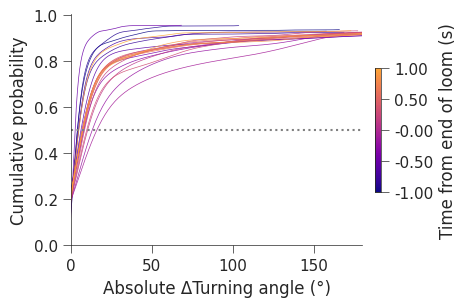

,-1.00s,-0.90s,-0.80s,-0.70s,-0.60s,-0.50s,-0.40s,-0.30s,-0.20s,-0.10s,...,0.10s,0.20s,0.30s,0.40s,0.50s,0.60s,0.70s,0.80s,0.90s,1.00s
0,0.052600,0.033856,0.063260,0.051508,0.051161,0.058106,0.054434,0.040835,0.030179,0.024242,...,0.025710,0.021741,0.032866,0.031761,0.028387,0.028655,0.040929,0.044499,0.034517,0.039917
1,0.443859,0.227958,0.444009,0.413455,0.439581,0.249098,0.448036,0.394890,0.316000,0.238454,...,0.306547,0.284868,0.372367,0.388238,0.343076,0.355093,0.394236,0.439002,0.416795,0.404997
2,0.630483,0.412277,0.620997,0.590205,0.641613,0.404232,0.653870,0.578485,0.456072,0.435509,...,0.480190,0.462801,0.518534,0.588425,0.550591,0.555479,0.583478,0.594533,0.590698,0.613222
3,0.710463,0.538473,0.723803,0.705354,0.728986,0.531980,0.727511,0.668356,0.522525,0.513934,...,0.577228,0.580671,0.587877,0.674179,0.680414,0.673348,0.676061,0.680722,0.677919,0.713571
4,0.772943,0.622977,0.773366,0.756153,0.798756,0.632637,0.777083,0.718317,0.573993,0.581949,...,0.626336,0.659193,0.638283,0.724491,0.761446,0.742522,0.759976,0.721729,0.718765,0.754204
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.998214,0.997917,0.997917,0.997917,0.995833,0.997917,0.995834,0.995833,0.993750,0.993750,...,0.995833,0.997917,0.997917,0.997917,0.991610,0.997917,0.995222,0.995833,0.993750,0.996429
96,0.998214,0.997917,0.997917,0.997917,0.995833,0.997917,0.997912,0.995833,0.993750,0.995823,...,0.995833,0.997917,0.997917,0.997917,0.993921,0.997917,0.995833,0.995836,0.995010,0.996643
97,0.998214,0.997917,0.997917,0.997917,0.996820,0.997917,0.997917,0.995843,0.993750,0.997884,...,0.995833,0.997917,0.997917,0.997917,0.997896,0.997917,0.995833,0.997914,0.997310,0.998214
98,0.998214,0.997917,0.997917,0.997917,0.997917,0.997938,0.997917,0.997916,0.996261,0.997917,...,0.996901,0.997917,0.997917,0.997917,0.997917,0.997917,0.995841,0.997917,0.997917,0.998214


In [ ]:
from scipy.special import ndtr
from scipy.stats import gaussian_kde

# cdf - use abs values
plt.figure(figsize=(4,3))
g = group_sizes[0]
for iw, w_name in enumerate(window_list):
  data = np.abs(pooled_dtheta[g][w_name])
  if len(data) == 0: continue
  color = cmap(norm(iw))
  sns.kdeplot(data, fill=False, c=color, alpha=0.9, cumulative=True, cut=1, lw=0.5)
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # required for older matplotlib versions

cbar = plt.colorbar(sm, ax=plt.gcf().axes, fraction=0.02, pad=0.04)
tick_locs = np.linspace(0, n_w-1, 5)
tick_labels = [f"{list(window_times.values())[int(i)][0]:.2f}" for i in tick_locs]

cbar.set_ticks(tick_locs); cbar.set_ticklabels(tick_labels); cbar.set_label('Time from end of loom (s)')
plt.xlabel('Absolute ΔTurning angle (°)'); plt.ylabel('Cumulative probability')
plt.xlim(0,180); plt.axhline(0.5,ls=':',color='grey')
sns.despine();
subpanel = 'S1o (rebuttal)'
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+f".pdf",bbox_inches='tight');
plt.show()

# save source data into csv
series_dict = {}
for iw, w_name in enumerate(window_times):
  data = np.abs(pooled_dtheta[g][w_name])
  kde = gaussian_kde(data)
  x_grid = np.linspace(data.min(), data.max(), 100)
  cdf = [ndtr((item - kde.dataset) / kde.factor).mean() for item in x_grid]
  col_name = f"{w_name}"
  series_dict[col_name] = pd.Series(cdf)

df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+'.csv', index=False)

# S1p - iid (bd) time series

/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S1p


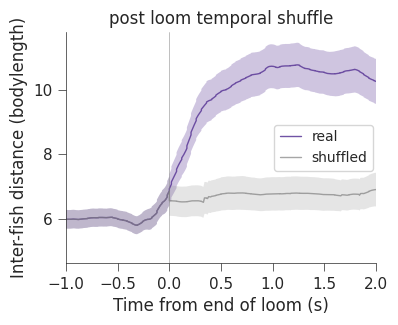

N = [20]
N shuffled = [20]


,real_1,real_2,real_3,real_4,real_5,real_6,real_7,real_8,real_9,real_10,...,shuffled_111,shuffled_112,shuffled_113,shuffled_114,shuffled_115,shuffled_116,shuffled_117,shuffled_118,shuffled_119,shuffled_120
0,9.392022,6.289748,7.389045,8.163789,12.247597,4.149030,7.401215,7.342293,3.513097,13.889242,...,4.127534,7.323985,9.784542,2.836944,8.886820,9.500217,2.740966,4.267784,9.166031,8.493265
1,9.404770,6.270066,7.422321,8.190094,12.252981,4.116670,7.397348,7.348473,3.588004,13.938053,...,4.141361,7.299711,9.755424,2.849144,8.919623,9.496945,2.673704,4.265608,9.168533,8.494588
2,9.416515,6.251679,7.444025,8.216507,12.265804,4.095532,7.413617,7.356318,3.645555,13.988799,...,4.138190,7.267744,9.726533,2.855699,8.950428,9.498219,2.624806,4.264026,9.171983,8.494646
3,9.427200,6.238514,7.462089,8.215512,12.278014,4.103640,7.461746,7.327863,3.718626,14.036944,...,4.138902,7.235759,9.695268,2.861075,9.007507,9.520404,2.588554,4.262205,9.185519,8.496883
4,9.436773,6.225032,7.478834,8.214454,12.290544,4.112700,7.536294,7.280274,3.750084,14.086262,...,4.122292,7.231780,9.694308,2.860606,9.056421,9.564833,2.571296,4.265747,9.199689,8.520447
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
358,17.722515,14.509265,12.773177,4.436812,12.140301,7.766537,12.114234,10.423088,2.281450,13.700405,...,3.967348,1.840589,1.868573,4.017955,5.594769,5.538171,10.004445,6.476752,6.823106,8.545084
359,17.713170,14.507400,12.627973,4.386304,12.107924,7.780289,12.091468,10.402586,2.282019,13.601127,...,3.976272,1.821277,1.865401,3.985497,5.606550,5.563747,9.944115,6.479394,6.779536,8.595427
360,17.705090,14.505888,12.500830,4.337472,12.078178,7.796599,12.062814,10.381799,2.267076,13.532548,...,3.984379,1.798966,1.864279,3.954509,5.599091,5.588696,9.926315,6.481716,6.754174,8.643870
361,17.662437,14.483505,12.354359,4.285423,12.049723,7.815207,12.037655,10.379737,2.268059,13.480622,...,3.998449,1.781636,1.848081,3.929020,5.586939,5.613603,9.891845,6.483792,6.730970,8.674637


In [ ]:
subpanel = 'S1p'

group_sizes = [4]
group_values = {n: [] for n in group_sizes}
group_values_shuffled = {n: [] for n in group_sizes}  # Add shuffled data storage
hex_colors = ['#61409b']

for exp in experiments[::]:
    load_path = save_path + exp + '/'; output_path = save_path + exp + '/'
    fish_num = metadata.fish_num[exp];
    if fish_num not in group_sizes: continue

    # load data
    data = np.load(load_path + 'lev0_basics.npz', allow_pickle=True)
    scale, fps, frame_num =  data['scale'], data['fps'], data['frame_num']
    f_bodylength_mm = data['f_bodylength_mm']

    data = np.load(load_path + 'lev0_group_basics.npz', allow_pickle=True)
    f_IID = data['f_IID']
    f_IID_bd = f_IID/np.mean(f_bodylength_mm)

    data = np.load(load_path + 'lev0_loom.npz', allow_pickle=True)
    loom_on, loom_len = data['loom_frames'][0], data['loom_len']; loom_off = loom_on + loom_len


    # closest distance - real data
    baseline = [np.mean(dist[loom_off-int(5*fps):loom_off]) for dist in f_IID_bd]
    tmp = [(dist/base) for dist, base in zip(f_IID_bd,baseline)]

    # Create shuffled version
    tmp_shuffled = []
    for dist in f_IID_bd:
      # shuffle post tap timeseries
      random_shift = np.random.randint(0, len(dist[:loom_on],))
      shuffled__post_dist = np.roll(dist[loom_off:], random_shift)
      shuffled_dist = np.concatenate((dist[:loom_off], shuffled__post_dist))

      tmp_shuffled.append(shuffled_dist)


    # append real data
    pair_num = f_IID.shape[0]
    for f in range(pair_num):
      group_values[fish_num].append(f_IID_bd[f][loom_off-int(30*121):loom_off+int(30*121)])
      group_values_shuffled[fish_num].append(tmp_shuffled[f][loom_off-int(30*121):loom_off+int(30*121)])

# make time_sec relative to loom_off for plotting
pre = np.linspace(-30,0,30*121); post = np.linspace(0,30,30*121)
rel_time = np.concatenate((pre,post)); rel_sec = np.round(rel_time,2)

# PLOT # mean+sem
plt.figure(figsize=[4,3])
for i, gs in enumerate(group_sizes):
  # Plot real data
  plt.plot(rel_sec,np.mean(group_values[gs],axis=0),linewidth=1,c=hex_colors[i],alpha=0.9,label='real')
  plt.fill_between(rel_sec, np.mean(group_values[gs],axis=0)-scipy.stats.sem(group_values[gs],axis=0), \
                    np.mean(group_values[gs],axis=0)+scipy.stats.sem(group_values[gs],axis=0),color=hex_colors[i],alpha=0.3,linewidth=0)

  # Plot shuffled data in grey
  plt.plot(rel_sec,np.mean(group_values_shuffled[gs],axis=0),linewidth=1,c='grey',alpha=0.7,label='shuffled')
  plt.fill_between(rel_sec, np.mean(group_values_shuffled[gs],axis=0)-scipy.stats.sem(group_values_shuffled[gs],axis=0), \
                    np.mean(group_values_shuffled[gs],axis=0)+scipy.stats.sem(group_values_shuffled[gs],axis=0),color='grey',alpha=0.2,linewidth=0)

plt.axvline(0,c='grey',linewidth=0.5, alpha=0.7)
plt.legend(bbox_to_anchor=(1,0.5),handlelength=1.5,markerscale=0.7,borderaxespad=0.2,fontsize=10)
plt.xlim(-1,2); plt.title('post loom temporal shuffle');
plt.xlabel('Time from end of loom (s)'); plt.ylabel('Inter-fish distance (bodylength)')
sns.despine();
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+".pdf",bbox_inches='tight');
plt.show()

print(f"N = {[int(len(group_values[g])/math.comb(4,2)) for g in group_sizes]}")
print(f"N shuffled = {[int(len(group_values_shuffled[g])/math.comb(4,2)) for g in group_sizes]}")

# save source data into csv - for time series, save out the visible part
ST, ED = -30, 30; st, ed = -1, 2; fps = 121

series_dict = {}
for group, samples in group_values.items():
  for i, sample in enumerate(samples):
    col_name = f"real_{i+1}"
    series_dict[col_name] = pd.Series(sample[(st-ST)*fps:(ed-ST)*fps])
for group, samples in group_values_shuffled.items():
  for i, sample in enumerate(samples):
    col_name = f"shuffled_{i+1}"
    series_dict[col_name] = pd.Series(sample[(st-ST)*fps:(ed-ST)*fps])

df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+'.csv', index=False)

# S1q - iid% long time series

/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S1q


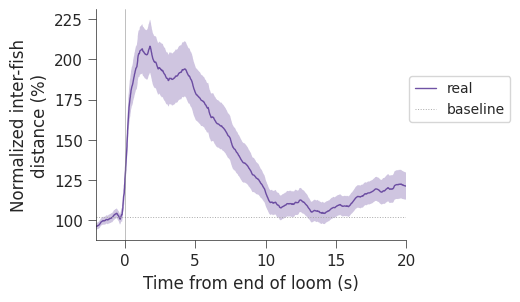

N = [20]
N shuffled = [20]


,real_1,real_2,real_3,real_4,real_5,real_6,real_7,real_8,real_9,real_10,...,shuffled_111,shuffled_112,shuffled_113,shuffled_114,shuffled_115,shuffled_116,shuffled_117,shuffled_118,shuffled_119,shuffled_120
0,111.825241,90.853830,81.389601,93.833235,99.343268,108.256657,99.738713,97.693281,75.486489,93.536134,...,87.145833,46.404897,161.100464,87.065220,113.524694,74.088361,76.112918,109.238158,153.789830,89.273053
1,111.863297,90.589318,81.370528,93.764467,99.338903,107.746996,99.440576,97.616245,75.744900,93.469667,...,86.942836,46.627494,160.642123,87.747293,113.744977,74.077616,76.307186,109.488478,153.377351,89.113017
2,111.895760,90.277900,81.170504,93.704905,99.151134,106.782014,99.154594,97.525262,75.997379,93.404131,...,86.762801,47.270933,160.149766,88.033272,113.975062,74.092766,76.505327,109.791889,153.389194,89.067876
3,112.148800,89.789714,81.156754,93.620384,99.188091,105.709605,99.146779,97.266197,75.966120,93.331254,...,86.807944,47.767296,159.676057,88.422611,114.028330,74.104716,76.690430,109.929154,153.407203,89.176796
4,112.164624,89.285184,81.138369,93.553883,99.178814,104.632294,99.421786,96.873043,75.268265,93.246815,...,87.051917,48.821982,159.803882,88.160782,114.065841,74.137311,76.959177,109.933781,153.413781,89.441301
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2657,150.634263,40.593337,123.009187,94.087505,19.799780,196.233729,152.812280,30.455673,48.863056,103.133170,...,21.857790,205.077080,193.356010,67.847880,59.312226,177.114818,25.386116,103.615206,48.928482,51.063399
2658,150.607327,40.464869,123.003842,94.304423,19.816106,196.735210,152.996179,30.291340,48.838130,103.142765,...,21.835328,204.068574,194.401529,67.159874,59.169522,177.070691,25.546863,104.335755,48.161011,50.829120
2659,150.580419,40.337184,123.004541,94.517241,19.806283,197.258411,153.175635,30.131534,48.828543,103.148485,...,21.855405,203.135476,195.305108,66.653429,59.053955,177.021665,25.568128,104.780398,47.649002,50.801199
2660,150.570353,40.218399,122.908030,94.730894,19.647945,197.631909,153.348508,29.985928,48.825773,103.154536,...,21.835700,202.157772,195.618497,66.310319,58.933800,177.343157,25.533179,105.056974,47.192693,50.594350


In [ ]:
subpanel = 'S1q'

group_sizes = [4]
group_values = {n: [] for n in group_sizes}
group_values_shuffled = {n: [] for n in group_sizes}  # Add shuffled data storage
hex_colors = ['#61409b']

for exp in experiments[::]:
    load_path = save_path + exp + '/'; output_path = save_path + exp + '/'
    fish_num = metadata.fish_num[exp];
    if fish_num not in group_sizes: continue

    # load data
    data = np.load(load_path + 'lev0_basics.npz', allow_pickle=True)
    scale, fps, frame_num =  data['scale'], data['fps'], data['frame_num']
    f_bodylength_mm = data['f_bodylength_mm']

    data = np.load(load_path + 'lev0_group_basics.npz', allow_pickle=True)
    f_IID = data['f_IID']
    f_IID_bd = f_IID/np.mean(f_bodylength_mm)

    data = np.load(load_path + 'lev0_loom.npz', allow_pickle=True)
    loom_on, loom_len = data['loom_frames'][0], data['loom_len']; loom_off = loom_on + loom_len

    # closest distance - real data
    baseline = [np.mean(dist[loom_off-int(5*fps):loom_off]) for dist in f_IID_bd]
    tmp = [(dist/base) for dist, base in zip(f_IID_bd,baseline)]

    # Create shuffled version
    tmp_shuffled = []
    for dist in f_IID_bd:
      # Roll each timeseries by a random amount
      random_shift = np.random.randint(0, len(dist))
      shuffled_dist = np.roll(dist, random_shift)

      # Calculate baseline after shuffling
      baseline_shuffled = np.mean(shuffled_dist[loom_off-int(1*fps):loom_off])
      tmp_shuffled.append(shuffled_dist/baseline_shuffled)

    # append real data
    pair_num = f_IID.shape[0]
    for f in range(pair_num):
      group_values[fish_num].append(tmp[f][loom_off-int(30*121):loom_off+int(30*121)]*100)
      group_values_shuffled[fish_num].append(tmp_shuffled[f][loom_off-int(30*121):loom_off+int(30*121)]*100)

# make time_sec relative to loom_off for plotting
pre = np.linspace(-30,0,30*121); post = np.linspace(0,30,30*121)
rel_time = np.concatenate((pre,post)); rel_sec = np.round(rel_time,2)

# PLOT # mean+sem
plt.figure(figsize=[4,3])
for i, gs in enumerate(group_sizes):
  # Plot real data
  plt.plot(rel_sec,np.mean(group_values[gs],axis=0),linewidth=1,c=hex_colors[i],alpha=0.9,label='real')
  plt.fill_between(rel_sec, np.mean(group_values[gs],axis=0)-scipy.stats.sem(group_values[gs],axis=0), \
                    np.mean(group_values[gs],axis=0)+scipy.stats.sem(group_values[gs],axis=0),color=hex_colors[i],alpha=0.3,linewidth=0)

  # Plot baseline (5-sec pre tap)
  tmp = np.array([t[24*121:29*121] for t in group_values[gs]]) # take 5s before tap
  baseline_mean = np.mean(np.mean(tmp))
  plt.axhline(baseline_mean,c='darkgray',linestyle=':',linewidth=0.7, label='baseline')

plt.axvline(0,c='grey',linewidth=0.5, alpha=0.7)
plt.legend(bbox_to_anchor=(1,0.5),handlelength=1.5,markerscale=0.7,borderaxespad=0.2,fontsize=10)
plt.xlim(-2,20);
plt.xlabel('Time from end of loom (s)'); plt.ylabel('Normalized inter-fish\ndistance (%)')
sns.despine();
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+".pdf",bbox_inches='tight');
plt.show()

print(f"N = {[int(len(group_values[g])/math.comb(4,2)) for g in group_sizes]}")
print(f"N shuffled = {[int(len(group_values_shuffled[g])/math.comb(4,2)) for g in group_sizes]}")

# save source data into csv - for time series, save out the visible part
ST, ED = -30, 30; st, ed = -2, 20; fps = 121

series_dict = {}
for group, samples in group_values.items():
  for i, sample in enumerate(samples):
    col_name = f"real_{i+1}"
    series_dict[col_name] = pd.Series(sample[(st-ST)*fps:(ed-ST)*fps])
for group, samples in group_values_shuffled.items():
  for i, sample in enumerate(samples):
    col_name = f"shuffled_{i+1}"
    series_dict[col_name] = pd.Series(sample[(st-ST)*fps:(ed-ST)*fps])

df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+'.csv', index=False)

# S1r - iid% traj shuffle time series

In [ ]:
def neighbor_stats(f_x, f_y, f_heading, scale):
  fish_num, frame_num = f_x.shape
  if f_y.shape[0] != fish_num: print('data compromised')

  # initialize arrays and lists
  ff_dist = np.zeros((fish_num,fish_num-1,frame_num))
  ff_align = np.zeros((fish_num,fish_num-1,frame_num))
  f_IID = []; f_IIA = [] # number of dyads x framenum
  f_closest_id = np.zeros((fish_num,frame_num))
  f_closest_dist = np.zeros((fish_num,frame_num))
  f_closest_align = np.zeros((fish_num,frame_num))

  # loop through ind fish
  for f0 in range(fish_num):
    nb_count = 0
    for f1 in range(fish_num):
      if f1 != f0:
        nb_count += 1
        dist = np.abs(np.sqrt( (f_x[f0]-f_x[f1])**2 + (f_y[f0]-f_y[f1])**2 ) )*scale
        align = ((( f_heading[f0]-f_heading[f1] ) + 180) % 360 - 180)
        ff_dist[f0][nb_count-1] = dist
        ff_align[f0][nb_count-1] = align
      if f0 < f1:
        f_IID.append(dist)
        f_IIA.append(align)
  f_IID = np.array(f_IID)
  f_IIA = np.array(f_IIA)

  # find the stats with the closest neighbor for each fish
  for f0 in range(fish_num):
    closest_dist = np.array(np.min(ff_dist[f0],axis=0)) # find the smallest dist in each frame
    f_closest_id[f0] = np.argmin(ff_dist[f0] == closest_dist, axis=0) # identify which fish it is
    index = f_closest_id[f0].astype(int)
    f_closest_dist[f0] = closest_dist # find their distance
    f_closest_align[f0] = ff_align[f0][index,np.arange(len(index))] # find their alignment

  return f_IID, f_IIA, f_closest_dist, f_closest_align

/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S1r


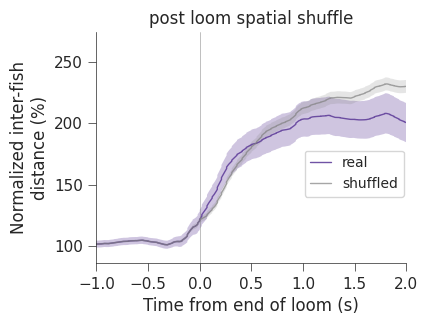

N = [20]
N shuffled = [20]


,real_1,real_2,real_3,real_4,real_5,real_6,real_7,real_8,real_9,real_10,...,shuffled_471,shuffled_472,shuffled_473,shuffled_474,shuffled_475,shuffled_476,shuffled_477,shuffled_478,shuffled_479,shuffled_480
0,119.773614,64.575930,79.843738,86.210215,104.983807,102.299265,99.569698,118.558155,60.958922,108.224351,...,121.732345,121.732345,121.732345,121.732345,121.732345,121.732345,121.732345,121.732345,121.732345,121.732345
1,119.936197,64.373859,80.203303,86.487999,105.029959,101.501395,99.517682,118.657943,62.258704,108.604690,...,121.556585,121.556585,121.556585,121.556585,121.556585,121.556585,121.556585,121.556585,121.556585,121.556585
2,120.085975,64.185082,80.437828,86.766926,105.139873,100.980223,99.736543,118.784621,63.257319,109.000094,...,121.462227,121.462227,121.462227,121.462227,121.462227,121.462227,121.462227,121.462227,121.462227,121.462227
3,120.222229,64.049918,80.633021,86.756414,105.244533,101.180132,100.384031,118.325150,64.525235,109.375242,...,121.585965,121.585965,121.585965,121.585965,121.585965,121.585965,121.585965,121.585965,121.585965,121.585965
4,120.344317,63.911498,80.813969,86.745245,105.351936,101.403525,101.386947,117.556714,65.071104,109.759522,...,121.879717,121.879717,121.879717,121.879717,121.879717,121.879717,121.879717,121.879717,121.879717,121.879717
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
358,226.009878,148.964518,138.022999,46.853064,104.064088,191.493211,162.974682,168.304653,39.587508,106.752942,...,146.809036,142.172003,136.185048,115.767309,156.814972,180.425998,180.520275,130.533231,164.533842,135.944172
359,225.890707,148.945364,136.453972,46.319690,103.786553,191.832288,162.668403,167.973607,39.597381,105.979372,...,146.625094,142.254363,136.178624,115.928237,156.810701,180.526770,180.809725,130.861953,164.690232,135.943086
360,225.787668,148.929843,135.080105,45.804028,103.531577,192.234441,162.282917,167.637948,39.338092,105.445014,...,146.513639,142.224569,136.074275,116.093549,156.705693,180.648951,181.012345,131.080215,164.863111,135.909910
361,225.243720,148.700045,133.497377,45.254381,103.287670,192.693232,161.944453,167.604662,39.355144,105.040402,...,146.396914,142.200336,135.980779,116.272535,156.610841,180.777821,181.228706,131.315017,165.043980,135.876488


In [ ]:
subpanel = 'S1r'

group_sizes = [4]
group_values = {n: [] for n in group_sizes}
group_values_shuffled = {n: [] for n in group_sizes}  # Add shuffled data storage
hex_colors = ['#61409b']

for exp in experiments[::]:
  load_path = save_path + exp + '/'; output_path = save_path + exp + '/'
  fish_num = metadata.fish_num[exp];
  if fish_num not in group_sizes: continue

  # load data
  data = np.load(load_path + 'lev0_basics.npz', allow_pickle=True)
  scale, fps, frame_num =  data['scale'], data['fps'], data['frame_num']
  f_bodylength_mm = data['f_bodylength_mm']
  f_x, f_y, f_heading = data['f_x'], data['f_y'], data['f_heading']

  data = np.load(load_path + 'lev0_loom.npz', allow_pickle=True)
  loom_on, loom_len = data['loom_frames'][0], data['loom_len']; loom_off = loom_on + loom_len

  # Real data
  f_IID, f_IIA, f_closest_dist, f_closest_align = neighbor_stats(f_x, f_y, f_heading, scale)
  f_IID_bd = f_IID/np.mean(f_bodylength_mm);
  f_closest_dist_bd = f_closest_dist/np.mean(f_bodylength_mm);

  baseline = [np.mean(dist[loom_off-int(5*fps):loom_off]) for dist in f_IID]
  normed_IID = [(dist/base) for dist, base in zip(f_IID,baseline)]

  # Create shuffled data
  mean_normed_IID_shuffled = []; n_iter = math.perm(fish_num)

  # Precompute escape displacements
  dx = f_x[:, loom_off:] - f_x[:, loom_off][:, None]
  dy = f_y[:, loom_off:] - f_y[:, loom_off][:, None]

  for it in range(n_iter):
    perm = np.random.permutation(fish_num)

    # Reassign trajectories to starting positions
    shuffled_x_post = f_x[:, loom_off][:, None] + dx[perm]
    shuffled_y_post = f_y[:, loom_off][:, None] + dy[perm]

    hybrid_x = np.hstack((f_x[:, :loom_off], shuffled_x_post))
    hybrid_y = np.hstack((f_y[:, :loom_off], shuffled_y_post))

    shuffled_IID, _, _, _ = neighbor_stats(hybrid_x, hybrid_y, f_heading, scale)

    baseline_shuffled = [np.mean(dist[loom_off-int(5*fps):loom_off]) for dist in shuffled_IID]
    normed_IID_shuffled = [dist / base for dist, base in zip(shuffled_IID, baseline_shuffled)]

    mean_normed_IID_shuffled.append(np.mean(normed_IID_shuffled, axis=0))

  mean_normed_IID_shuffled = np.array(mean_normed_IID_shuffled)

  # append data
  for f in range(f_IID.shape[0]):
    group_values[fish_num].append(normed_IID[f][loom_off-int(30*121):loom_off+int(30*121)]*100)
  for f in range(mean_normed_IID_shuffled.shape[0]):
    group_values_shuffled[fish_num].append(mean_normed_IID_shuffled[f][loom_off-int(30*121):loom_off+int(30*121)]*100)

# make time_sec relative to loom_off for plotting
pre = np.linspace(-30,0,30*121); post = np.linspace(0,30,30*121)
rel_time = np.concatenate((pre,post)); rel_sec = np.round(rel_time,2)

# PLOT # mean+sem
plt.figure(figsize=[4,3])
for i, gs in enumerate(group_sizes):
  # Plot real data
  plt.plot(rel_sec,np.mean(group_values[gs],axis=0),linewidth=1,c=hex_colors[i],alpha=0.9,label='real')
  plt.fill_between(rel_sec, np.mean(group_values[gs],axis=0)-scipy.stats.sem(group_values[gs],axis=0), \
                    np.mean(group_values[gs],axis=0)+scipy.stats.sem(group_values[gs],axis=0),color=hex_colors[i],alpha=0.3,linewidth=0)

  # Plot shuffled data in grey
  plt.plot(rel_sec,np.mean(group_values_shuffled[gs],axis=0),linewidth=1,c='grey',alpha=0.7,label='shuffled')
  plt.fill_between(rel_sec, np.mean(group_values_shuffled[gs],axis=0)-scipy.stats.sem(group_values_shuffled[gs],axis=0), \
                    np.mean(group_values_shuffled[gs],axis=0)+scipy.stats.sem(group_values_shuffled[gs],axis=0),color='grey',alpha=0.2,linewidth=0)

plt.axvline(0,c='grey',linewidth=0.5, alpha=0.7)
plt.legend(bbox_to_anchor=(1,0.5),handlelength=1.5,markerscale=0.7,borderaxespad=0.2,fontsize=10)
plt.xlim(-1,2); plt.title('post loom spatial shuffle');
plt.xlabel('Time from end of loom (s)'); plt.ylabel('Normalized inter-fish\ndistance (%)')
sns.despine();
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+".pdf",bbox_inches='tight');
plt.show()

print(f"N = {[int(len(group_values[g])/math.comb(4,2)) for g in group_sizes]}")
print(f"N shuffled = {[int(len(group_values_shuffled[g])/math.perm(g)) for g in group_sizes]}")

# save source data into csv - for time series, save out the visible part
ST, ED = -30, 30; st, ed = -1, 2; fps = 121

series_dict = {}
for group, samples in group_values.items():
  for i, sample in enumerate(samples):
    col_name = f"real_{i+1}"
    series_dict[col_name] = pd.Series(sample[(st-ST)*fps:(ed-ST)*fps])
for group, samples in group_values_shuffled.items():
  for i, sample in enumerate(samples):
    col_name = f"shuffled_{i+1}"
    series_dict[col_name] = pd.Series(sample[(st-ST)*fps:(ed-ST)*fps])

df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+'.csv', index=False)